In [ ]:
p|# MUST run before importing ultralytics / torch.distributed code
import os

# Kill Weights & Biases auto-init inside DDP workers
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_SILENT"] = "true"

# Make multi-GPU comms less flaky on cloud boxes
os.environ.setdefault("NCCL_P2P_DISABLE", "1")
os.environ.setdefault("NCCL_IB_DISABLE", "1")

# Avoid CUDA alloc fragmentation
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "max_split_size_mb:128")


SyntaxError: invalid syntax (ipython-input-3575166528.py, line 1)

In [ ]:
'


# If Ray is installed, Ultralytics loads the raytune callback and it breaks at epoch end.
|


# Removing Ray = no raytune import = no crash.
!pip uninstall -y ray ray[default] ray[tune]


SyntaxError: unterminated string literal (detected at line 1) (ipython-input-520568114.py, line 1)

In [ ]:
# Optional but recommended: newer bugfixes.
!pip install -U ultralytics==8.3.191


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.7 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CSSrZ2rp40dMdCdLorPl")
project = rf.workspace("rdd-lkcpo").project("posture-detection-y1top")
version = project.version(10)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Posture-Detection-10 in yolov8:: 100%|██████████| 7064/7064 [00:02<00:00, 3359.43it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import yaml
# Load dataset configuration
dataset_path = "/kaggle/working/Posture-Detection-10"
with open(f"{dataset_path}/data.yaml", 'r') as file:
    data_config = yaml.safe_load(file)

print("DATASET CONFIGURATION SUMMARY")

print(f"Number of Classes: {data_config['nc']}")
print(f"Class Names: {data_config['names']}")
print(f"Train Path: {data_config['train']}")
print(f"Validation Path: {data_config['val']}")
print(f"Test Path: {data_config['test']}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/Posture-Detection-10/data.yaml'

In [ ]:

# Count images in each split
splits = ['train', 'valid', 'test']
dataset_stats = {}

for split in splits:
    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')

    if os.path.exists(images_path):
        # Count images
        image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        image_count = len(image_files)

        # Count annotations
        label_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
        label_count = len(label_files)

        dataset_stats[split] = {
            'images': image_count,
            'labels': label_count
        }

        print(f"{split.capitalize()} Set:")
        print(f"  - Images: {image_count}")
        print(f"  - Labels: {label_count}")
        print(f"  - Coverage: {(label_count/image_count)*100:.1f}%")

In [ ]:



globalfrom ultralytics import YOLO
from IPython.display import display, Image

import matplotlib.pyplot as plt

import cv2
import glob
from PIL import Image as PILImage
import random
from collections import Counter

import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


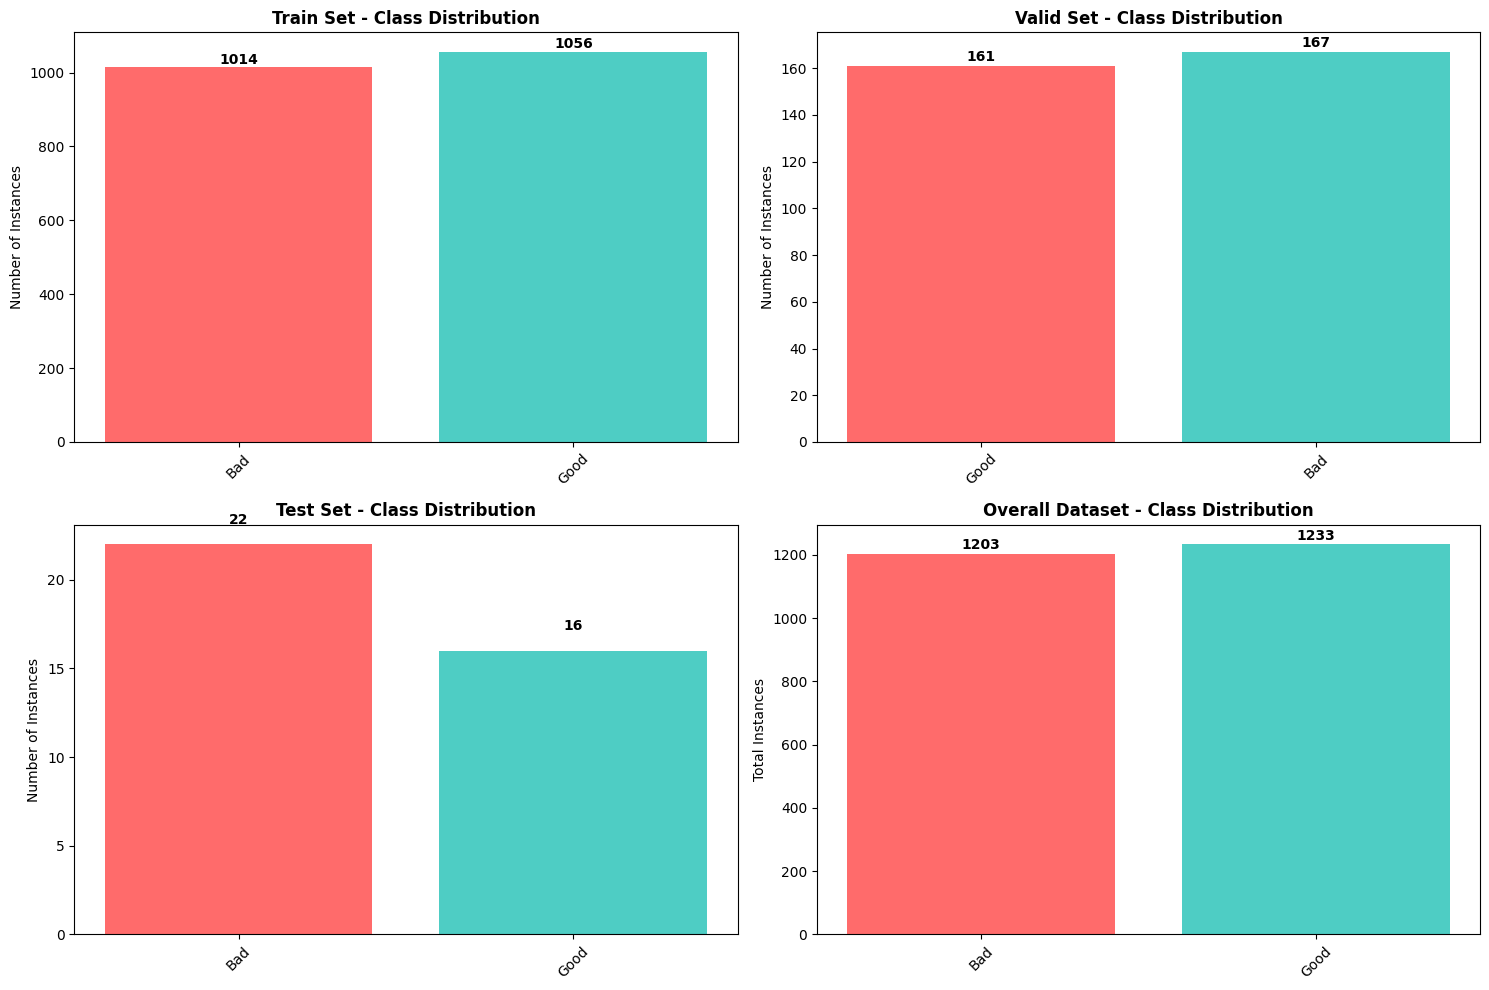

In [ ]:
def analyze_class_distribution(dataset_path, split):
    """Analyze class distribution in a dataset split"""
    labels_path = os.path.join(dataset_path, split, 'labels')
    class_counts = Counter()

    if os.path.exists(labels_path):
        for label_file in os.listdir(labels_path):
            if label_file.endswith('.txt'):
                with open(os.path.join(labels_path, label_file), 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        if line.strip():
                            class_id = int(line.split()[0])
                            class_counts[class_id] += 1

    return class_counts

# Analyze class distribution for all splits
class_distribution = {}
for split in splits:
    class_distribution[split] = analyze_class_distribution(dataset_path, split)

# Create comprehensive class distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
class_names = data_config['names']

# Individual split analysis
for idx, split in enumerate(splits):
    ax = axes[idx//2, idx%2] if idx < 3 else None
    if ax and class_distribution[split]:
        classes = list(class_distribution[split].keys())
        counts = list(class_distribution[split].values())
        class_labels = [class_names[c] for c in classes]

        bars = ax.bar(class_labels, counts, color=['#FF6B6B', '#4ECDC4'])
        ax.set_title(f'{split.capitalize()} Set - Class Distribution', fontweight='bold')
        ax.set_ylabel('Number of Instances')
        ax.tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{count}', ha='center', va='bottom', fontweight='bold')

# Overall distribution
ax_overall = axes[1, 1]
overall_counts = Counter()
for split_counts in class_distribution.values():
    overall_counts.update(split_counts)

if overall_counts:
    overall_classes = list(overall_counts.keys())
    overall_class_counts = list(overall_counts.values())
    overall_labels = [class_names[c] for c in overall_classes]

    bars = ax_overall.bar(overall_labels, overall_class_counts,
                         color=['#FF6B6B', '#4ECDC4'])
    ax_overall.set_title('Overall Dataset - Class Distribution', fontweight='bold')
    ax_overall.set_ylabel('Total Instances')
    ax_overall.tick_params(axis='x', rotation=45)

    # Add value labels
    for bar, count in zip(bars, overall_class_counts):
        height = bar.get_height()
        ax_overall.text(bar.get_x() + bar.get_width()/2., height + 5,
                       f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

TRAINING SET SAMPLE VISUALIZATION


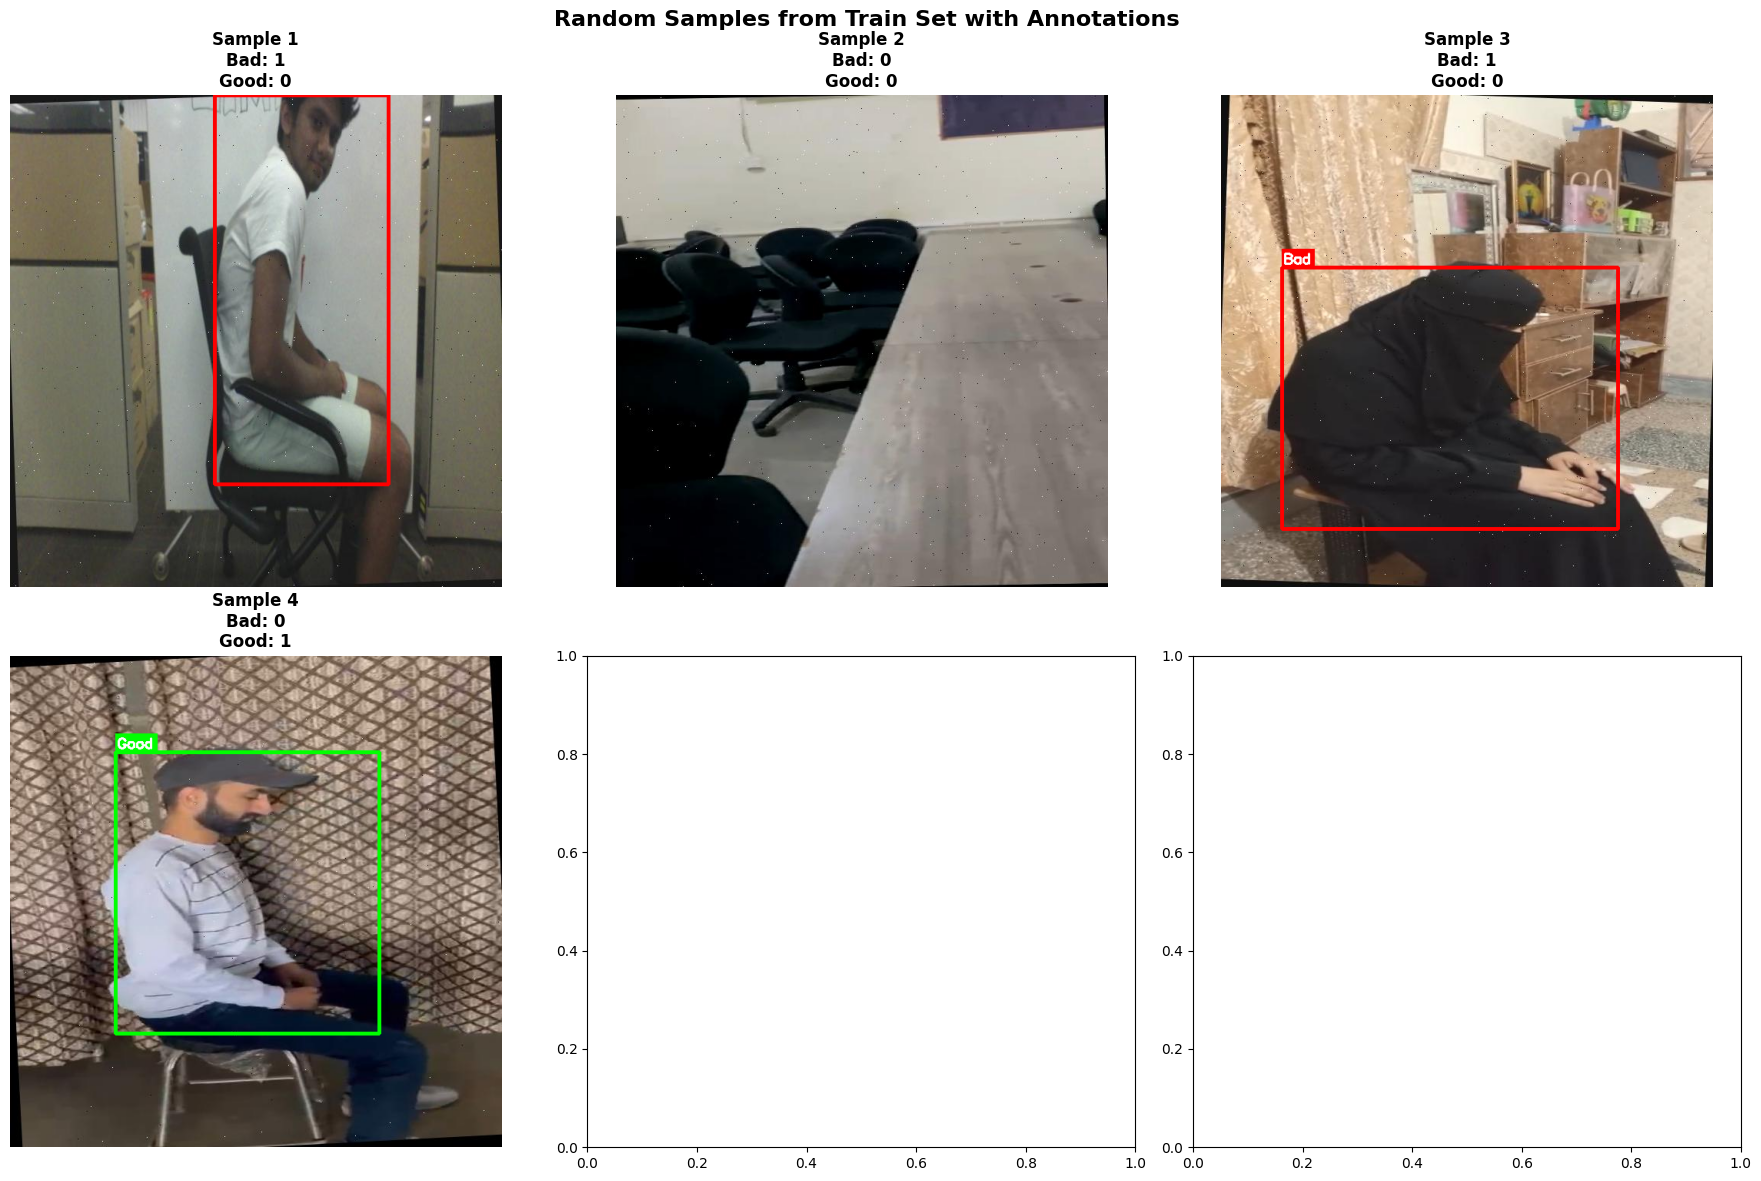

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
def visualize_samples_with_annotations(dataset_path, split='train', num_samples=4):
    """Visualize random sample images with their bounding box annotations"""


    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')

    # Get random sample of images
    image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    colors = [(255, 0, 0), (0, 255, 0)]  # Red for ACCIDENT, Green for NON_ACCIDENT

    for idx, image_file in enumerate(sample_files):
        # Load image
        image_path = os.path.join(images_path, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Load corresponding label file
        label_file = os.path.splitext(image_file)[0] + '.txt'
        label_path = os.path.join(labels_path, label_file)

        # Initialize annotation_count based on class_names from data_config
        annotation_count = {name: 0 for name in class_names}


        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                annotations = f.readlines()

            for annotation in annotations:
                parts = annotation.strip().split()
                if len(parts) >= 5:
                    class_id, x_center, y_center, width, height = map(float, parts[:5])
                    class_id = int(class_id)

                    # Convert YOLO format to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h

                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)

                    # Draw bounding box
                    color = colors[class_id % len(colors)]
                    cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)

                    # Add class label
                    class_name = class_names[class_id]
                    if class_name in annotation_count:
                         annotation_count[class_name] += 1
                    label_text = f'{class_name}'

                    # Calculate text size and position
                    (text_width, text_height), baseline = cv2.getTextSize(
                        label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
                    )

                    # Draw label background
                    cv2.rectangle(image, (x1, y1 - text_height - 10),
                                (x1 + text_width + 5, y1), color, -1)

                    # Draw label text
                    cv2.putText(image, label_text, (x1 + 2, y1 - 5),
                              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # Display the image
        axes[idx].imshow(image)
        # Update the title to reflect the actual class names in the counts
        title_text = f'Sample {idx+1}'
        for name, count in annotation_count.items():
            title_text += f'\n{name}: {count}'
        axes[idx].set_title(title_text, fontweight='bold')
        axes[idx].axis('off')

    plt.suptitle(f'Random Samples from {split.capitalize()} Set with Annotations',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize training samples
print("TRAINING SET SAMPLE VISUALIZATION")
visualize_samples_with_annotations('/kaggle/working/Posture-Detection-10', 'train', 4)

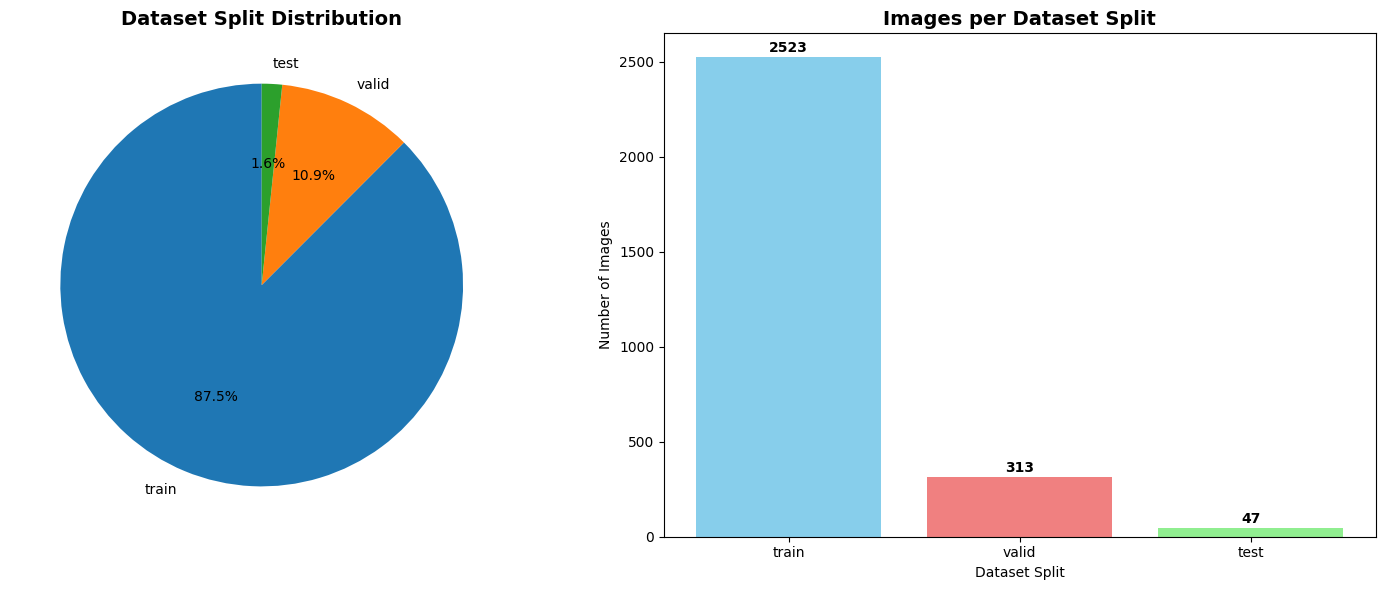

In [ ]:
# Create visualization of dataset distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Dataset split distribution
splits_names = list(dataset_stats.keys())
image_counts = [dataset_stats[split]['images'] for split in splits_names]

ax1.pie(image_counts, labels=splits_names, autopct='%1.1f%%', startangle=90)
ax1.set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')

# Bar chart for better comparison
ax2.bar(splits_names, image_counts, color=['skyblue', 'lightcoral', 'lightgreen'])
ax2.set_title('Images per Dataset Split', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Images')
ax2.set_xlabel('Dataset Split')

# Add value labels on bars
for i, v in enumerate(image_counts):
    ax2.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import sys, platform, torch
from ultralytics import YOLO

print(f"Python {sys.version.split()[0]} | Torch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f" - GPU {i}: {torch.cuda.get_device_name(i)}")
assert torch.cuda.device_count() >= 2, "Need 2 GPUs visible."


Python 3.11.13 | Torch 2.6.0+cu124 | CUDA True | GPUs 2
 - GPU 0: Tesla T4
 - GPU 1: Tesla T4


In [ ]:
# Your dataset YAML (from Roboflow export)
DATA_YAML = "/kaggle/working/Posture-Detection-10/data.yaml"

# Model + training settings
MODEL_NAME = "yolov8s.pt"  # try 'yolov8n.pt' if VRAM tight; 'yolov8m.pt' if you want a bit more accuracy
IMGSZ      = 640          # bump to 640 only if you miss tiny objects
EPOCHS     = 100
BATCH      = 64            # total across both GPUs (≈32 per GPU on T4 @512 is fine)
DEVICE     = "0,1"         # use both GPUs
PROJECT    = "runs"
RUN_NAME   = "rf_yolov8m_512px_v12"  # keep your naming

train_kwargs = dict(
    data=DATA_YAML,
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH,
    device=DEVICE,      # triggers DDP
    workers=8,
    amp=True,
    cache="ram",        # fast; switch to 'disk' for stricter determinism
    patience=25,
    project=PROJECT,
    name=RUN_NAME,
    verbose=True,
    deterministic=True,
)
train_kwargs


{'data': '/kaggle/working/Posture-Detection-10/data.yaml',
 'imgsz': 640,
 'epochs': 100,
 'batch': 64,
 'device': '0,1',
 'workers': 8,
 'amp': True,
 'cache': 'ram',
 'patience': 25,
 'project': 'runs',
 'name': 'rf_yolov8m_512px_v12',
 'verbose': True,
 'deterministic': True}

In [ ]:
%pip install --upgrade --no-cache-dir \
  "numpy==2.2.6" \
  "matplotlib>=3.9.0" \
  "scipy>=1.11.4" \
  "shapely>=2.0.4" \
  --force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 277.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 320.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 217.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 264.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 328.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 320.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 328.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 318.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 341.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 264.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 141.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━

In [ ]:
model = YOLO(MODEL_NAME)   # COCO-pretrained
results = model.train(**train_kwargs)
results


New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.191 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                        CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Posture-Detection-10/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, mom

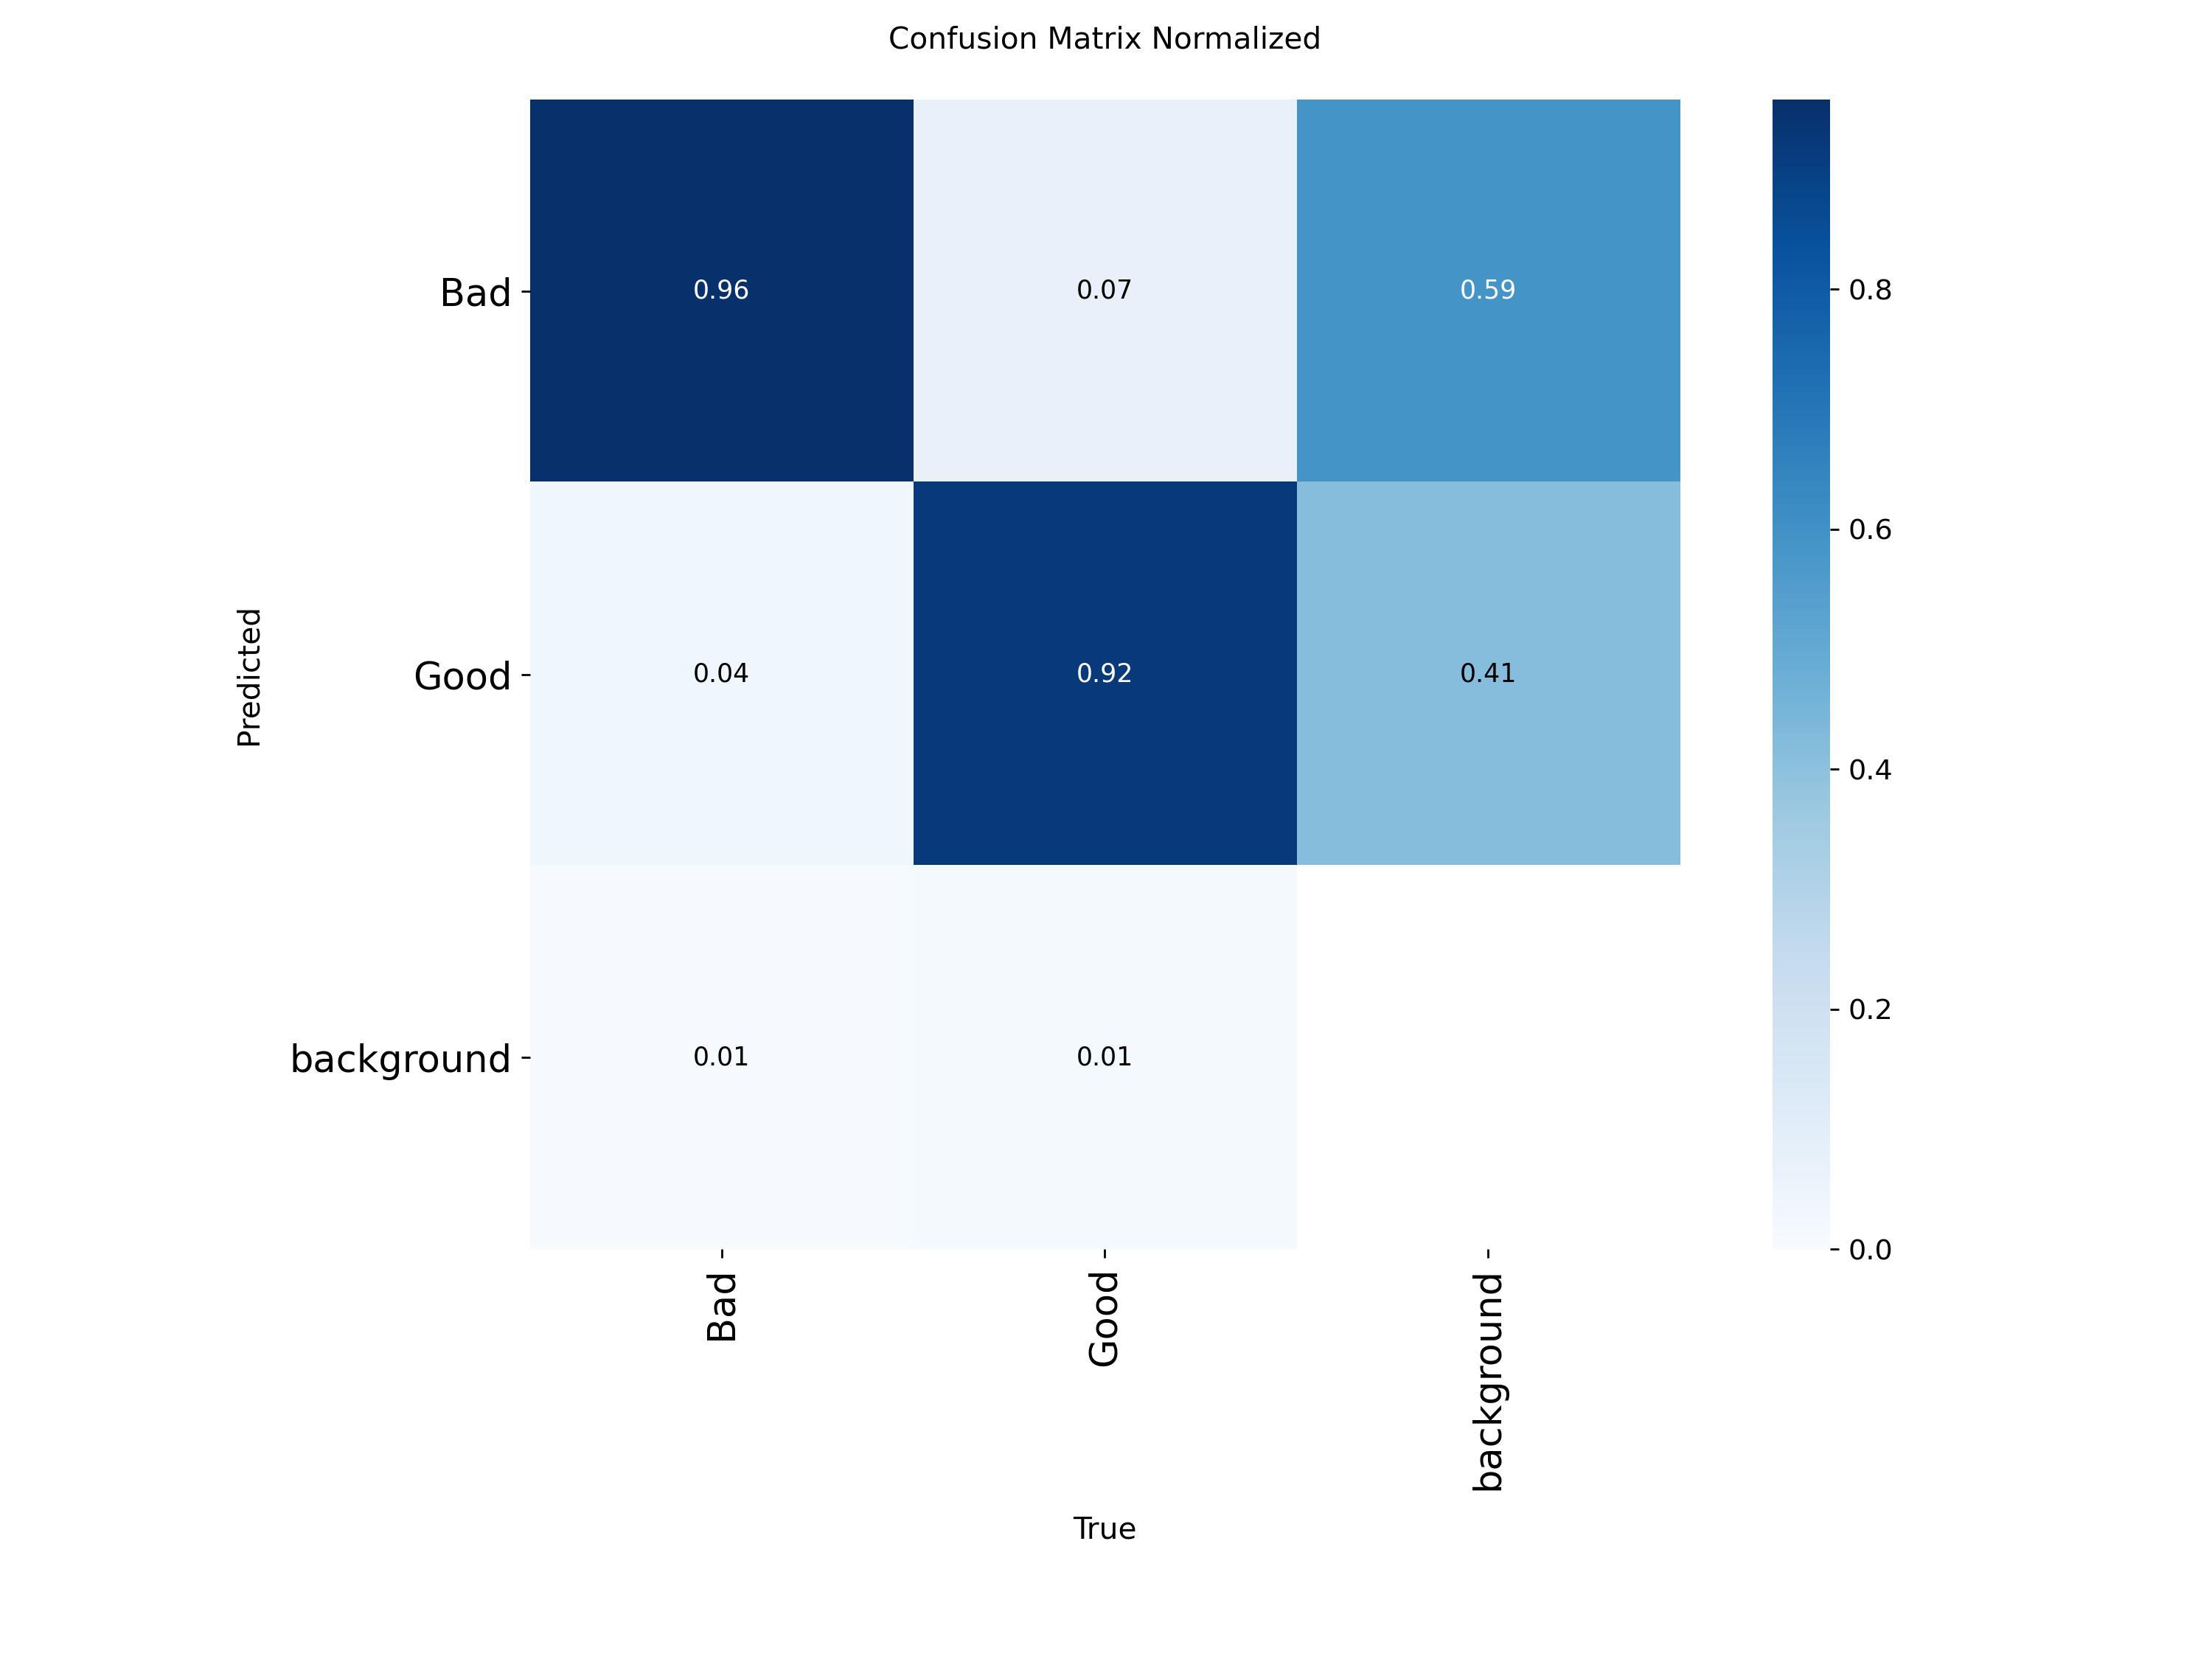

In [ ]:

Image(filename='/kaggle/working/runs/rf_yolov8m_512px_v12/confusion_matrix_normalized.png', width=600)

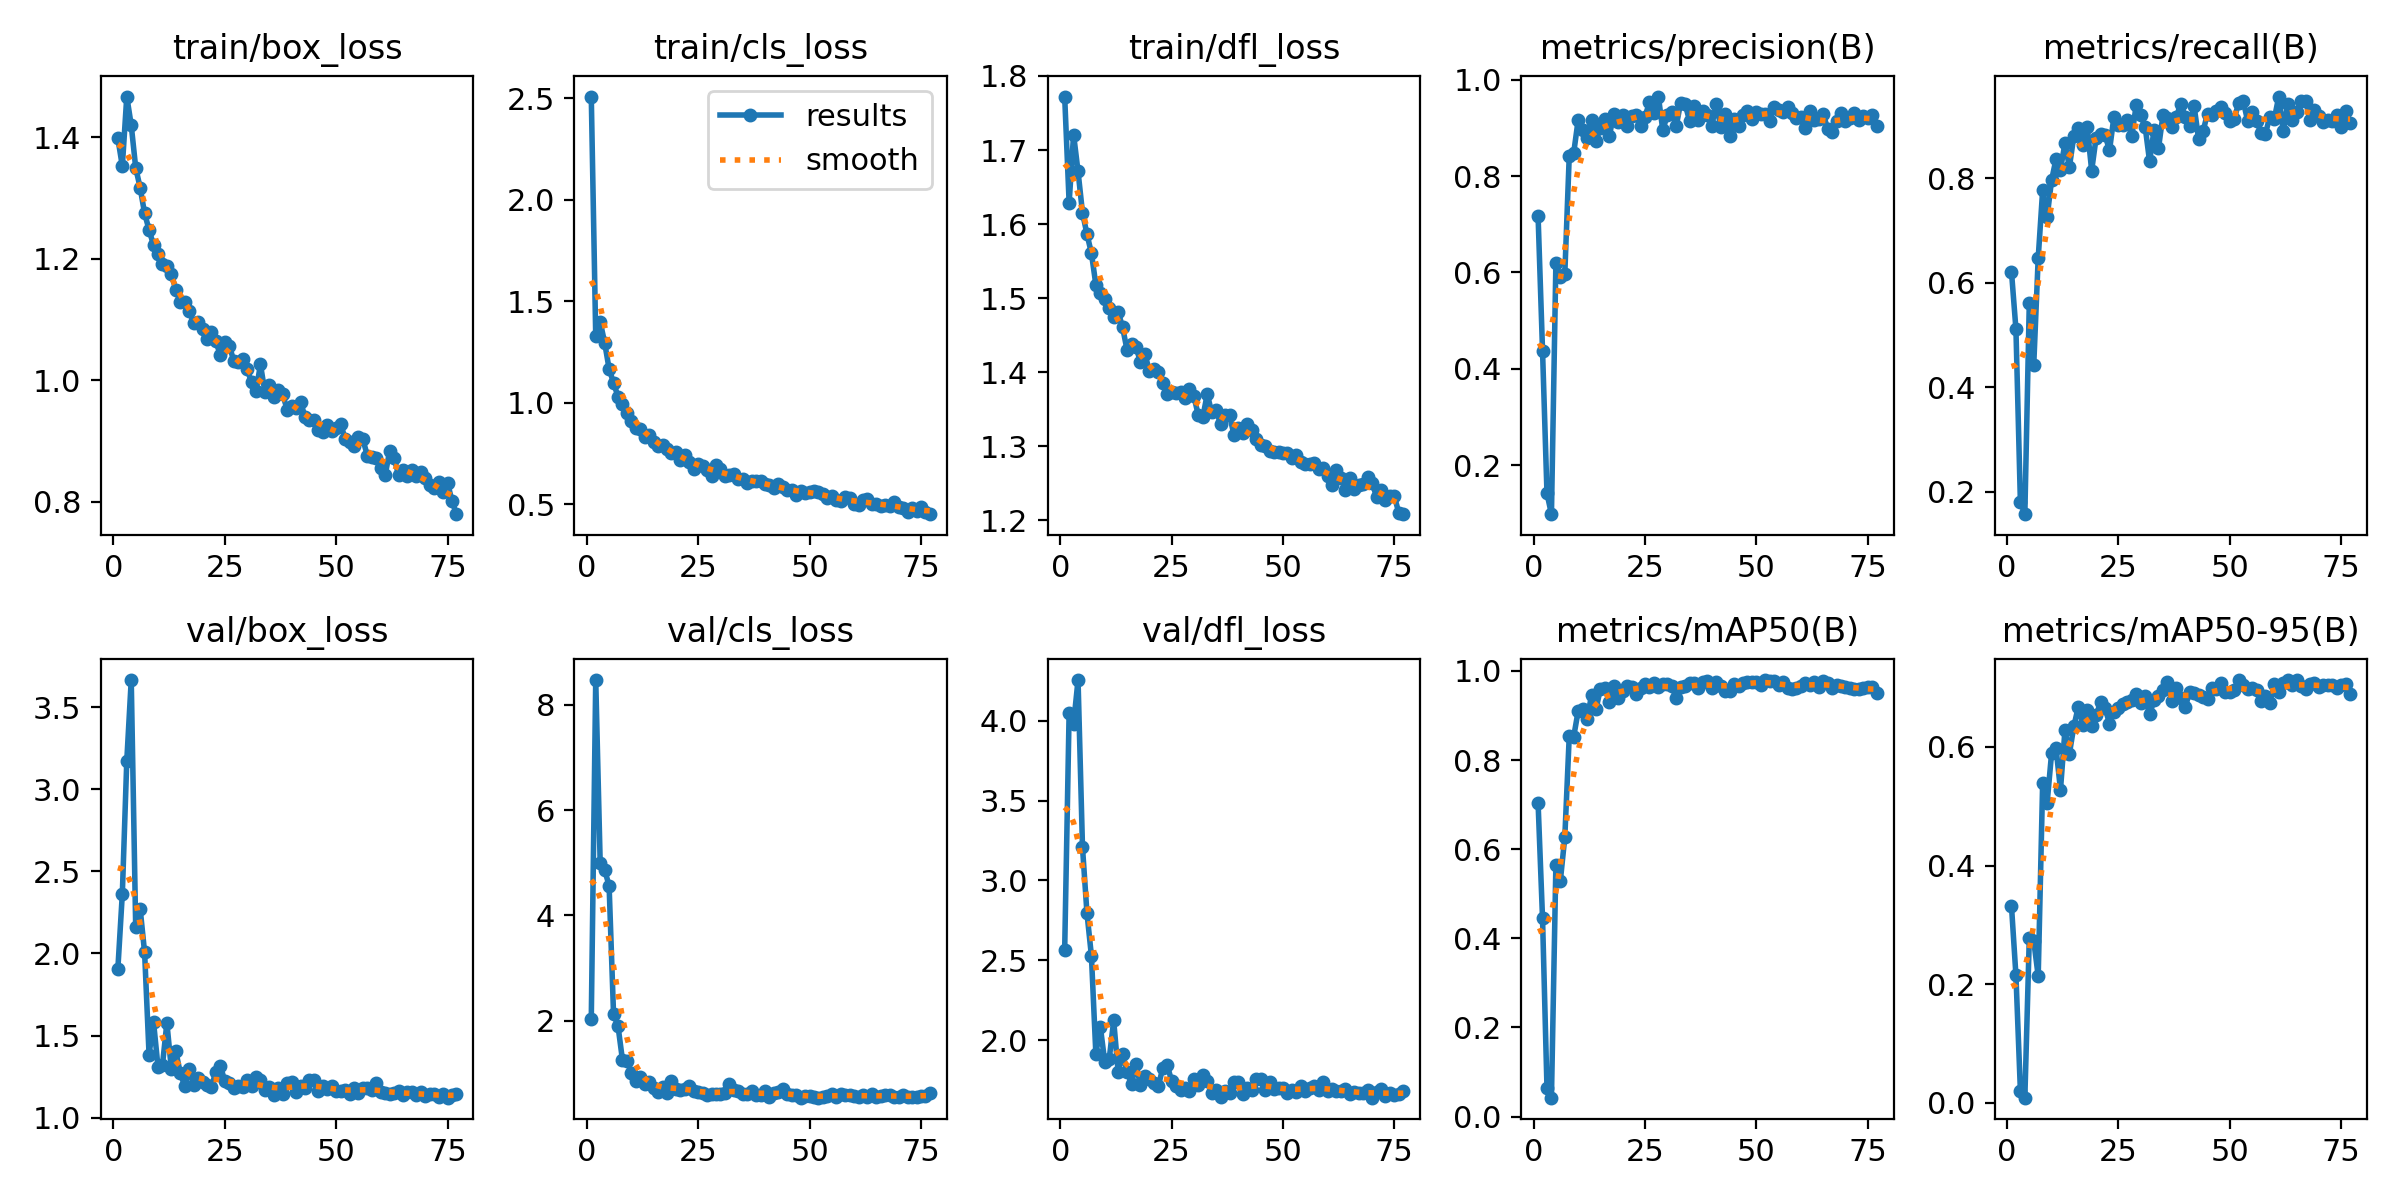

In [ ]:
Image(filename='/kaggle/working/runs/rf_yolov8m_512px_v12/results.png', width=800)

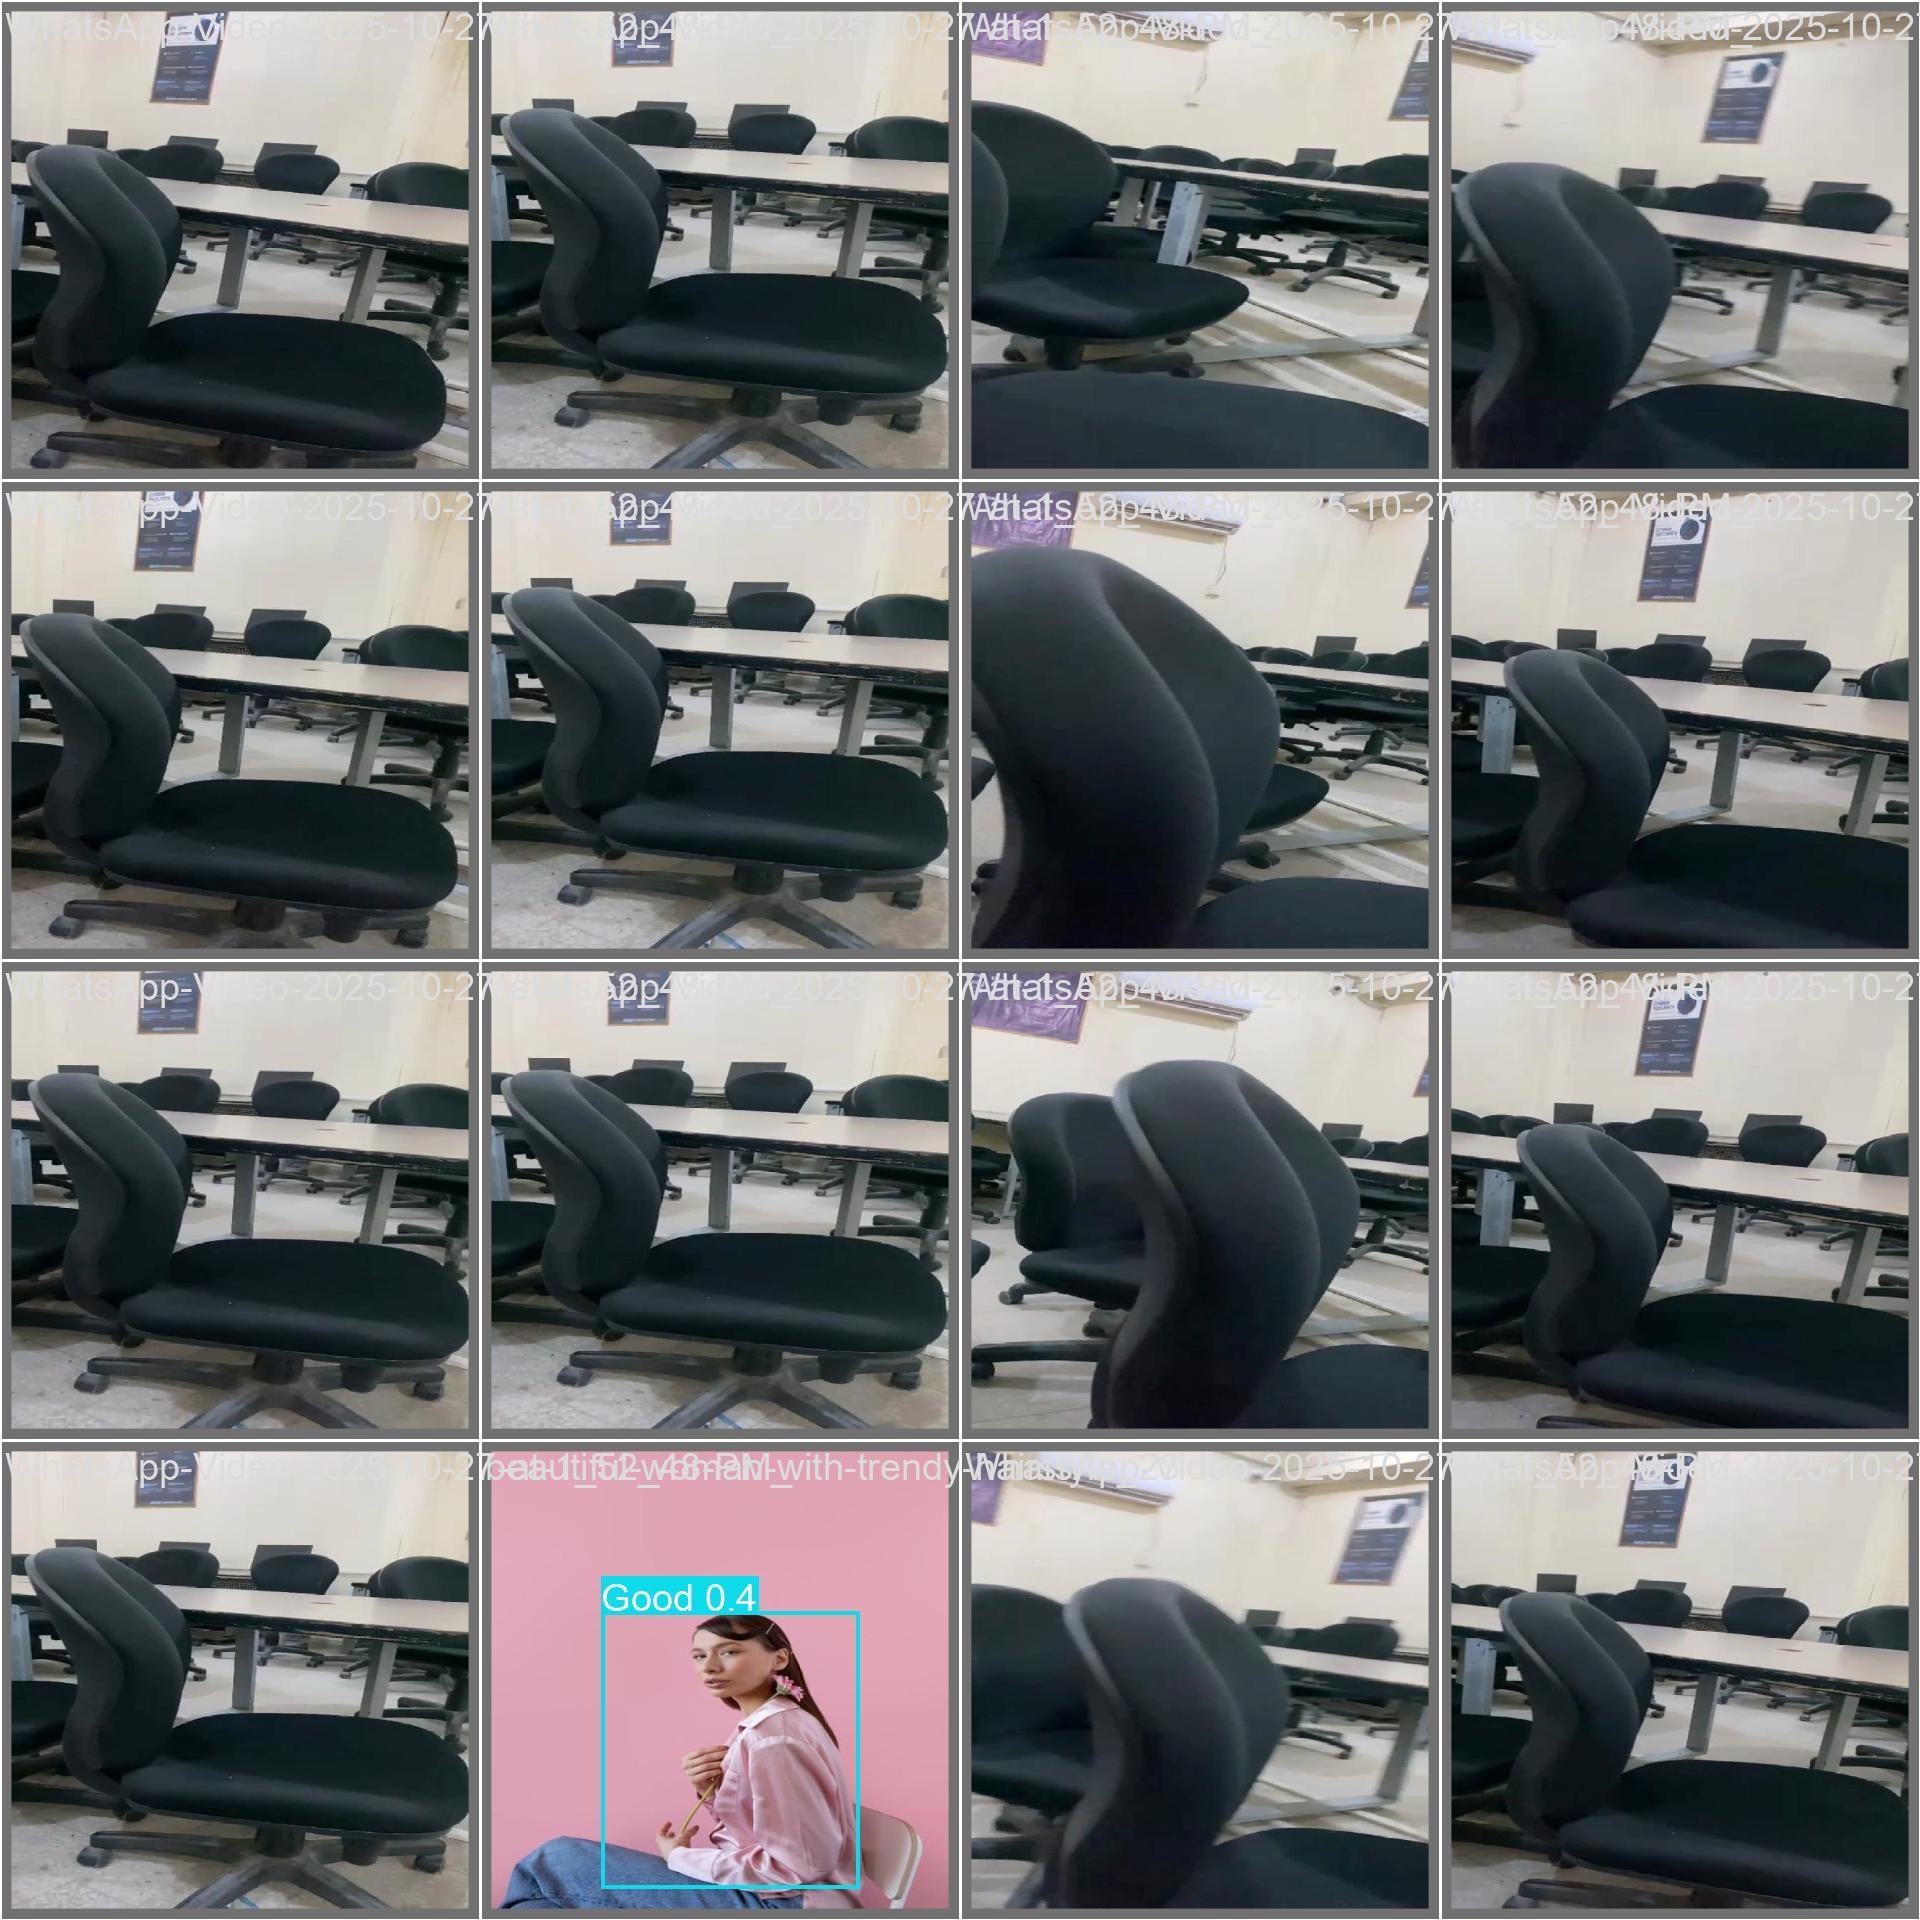

In [ ]:
Image(filename='/kaggle/working/runs/rf_yolov8m_512px_v12/val_batch0_pred.jpg', width=900)

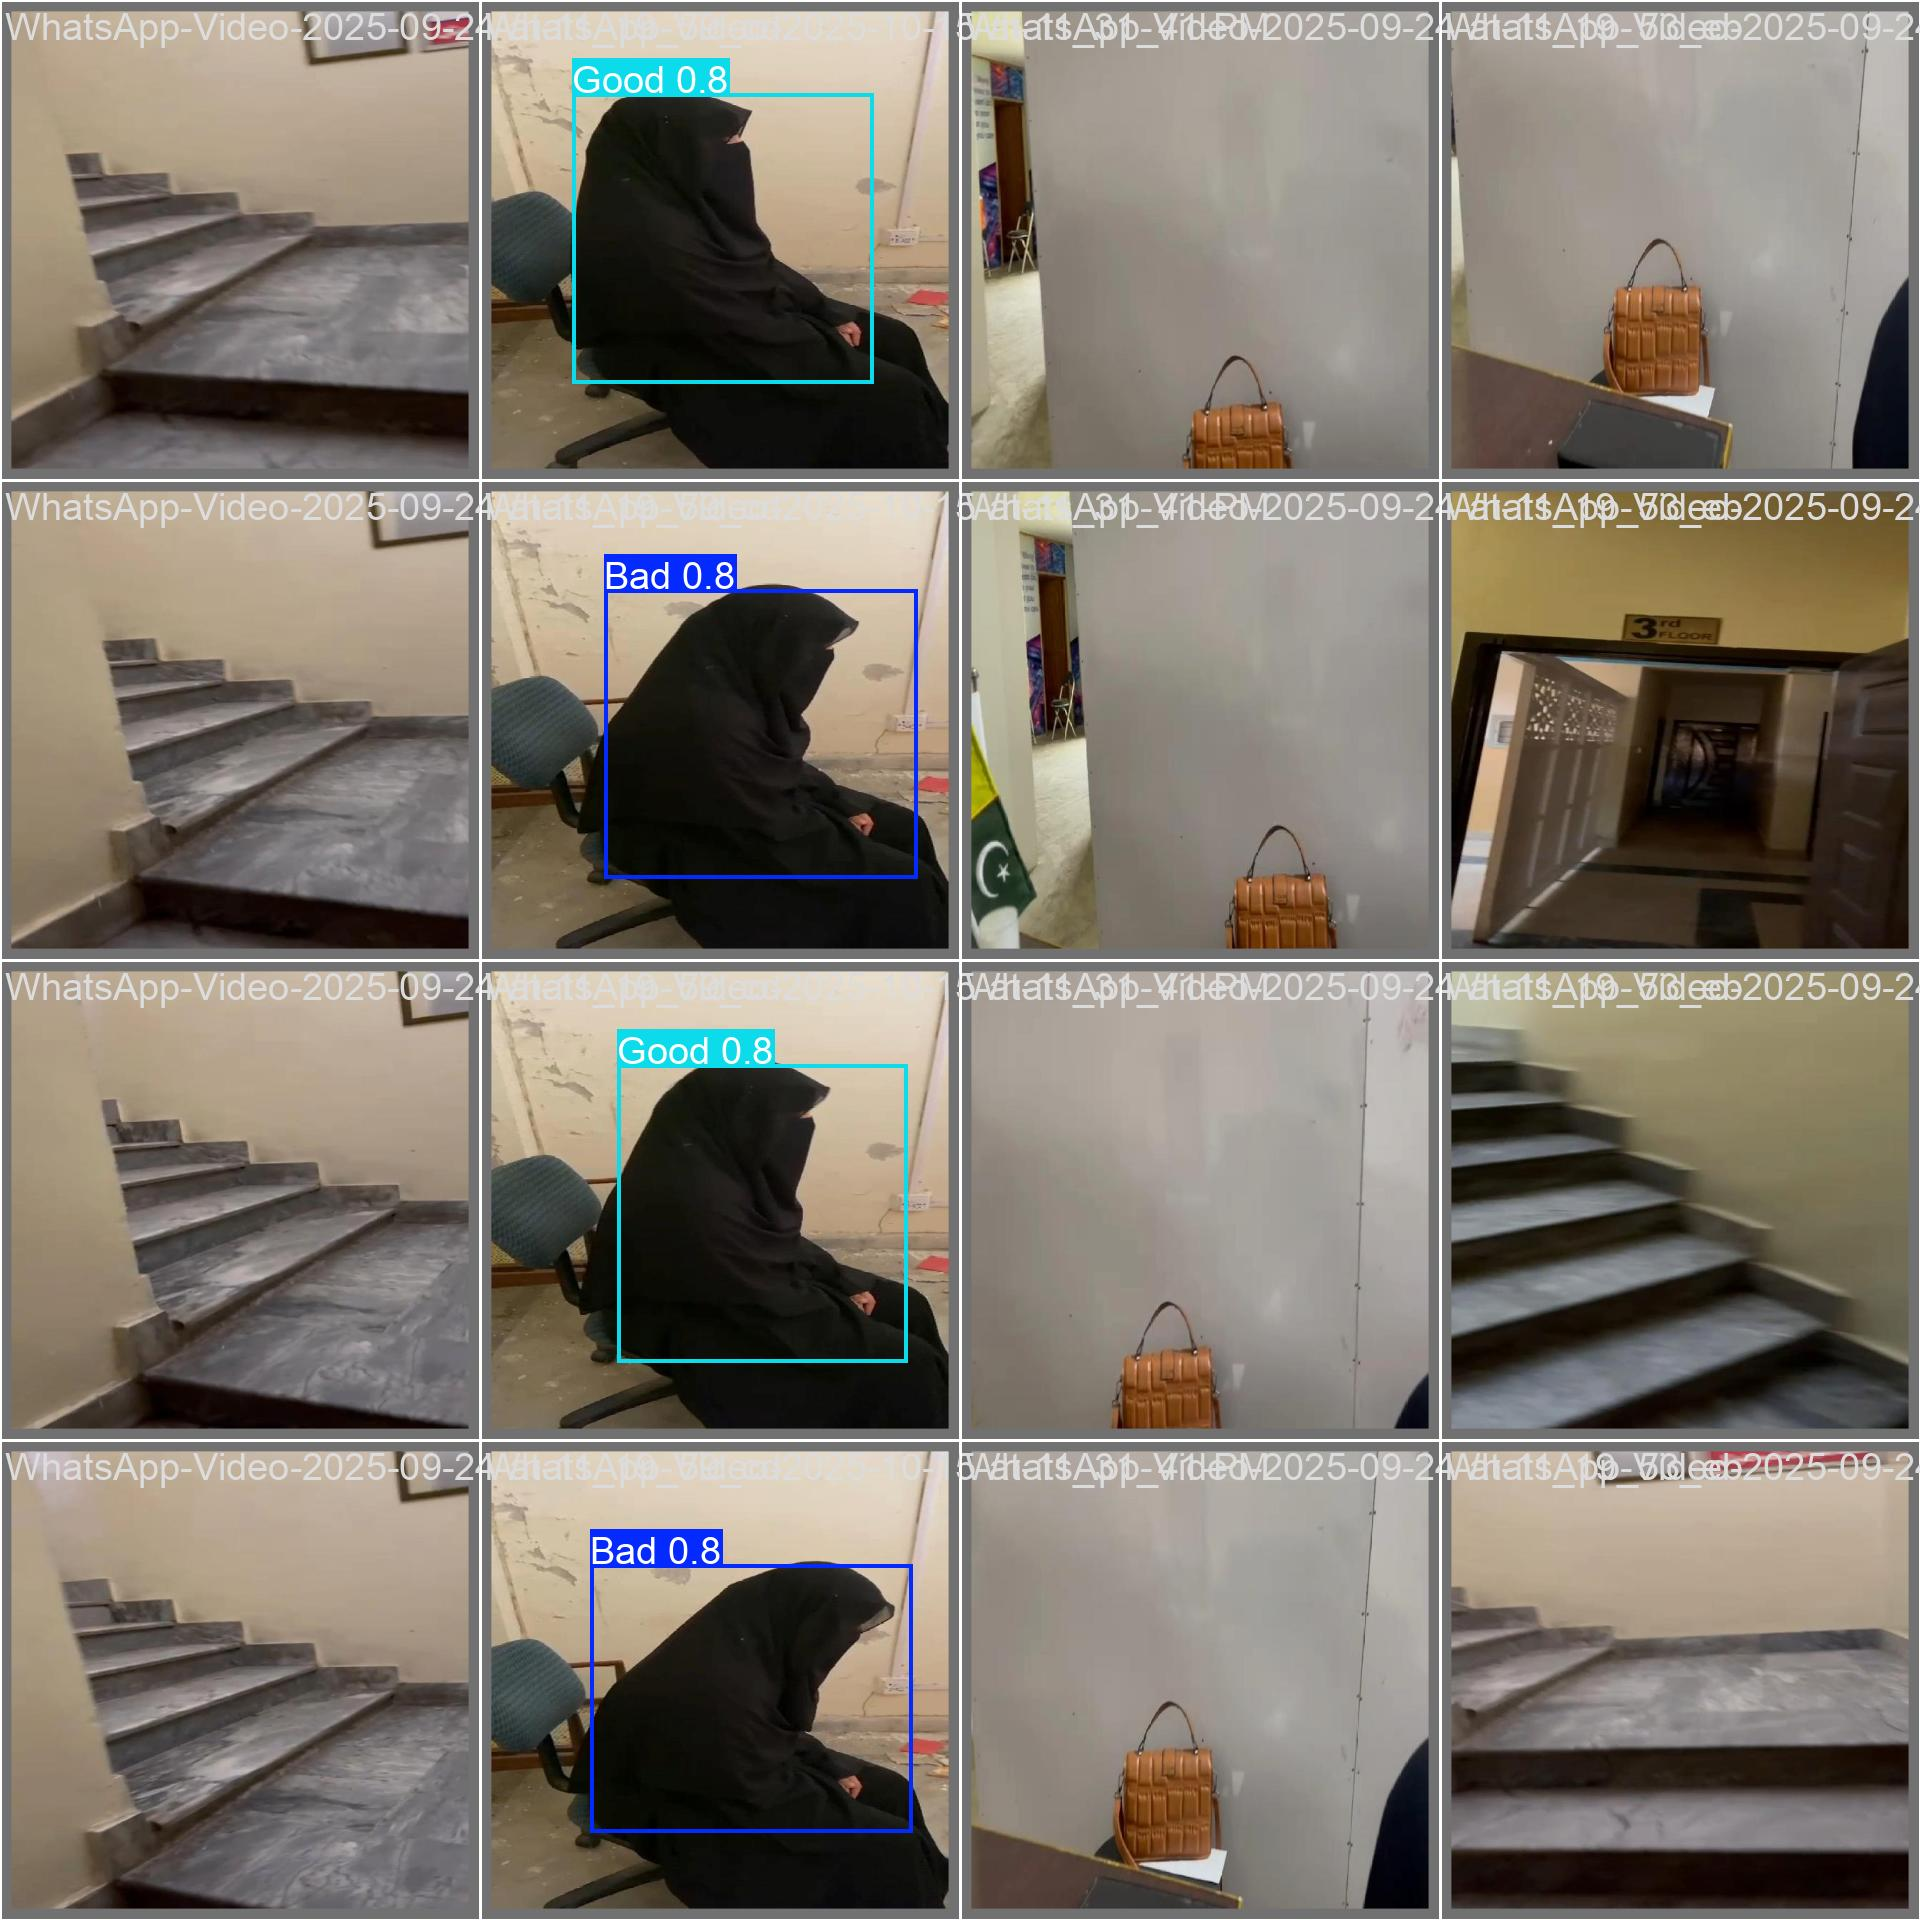

In [ ]:
Image(filename='/kaggle/working/runs/rf_yolov8m_512px_v12/val_batch1_pred.jpg', width=900)

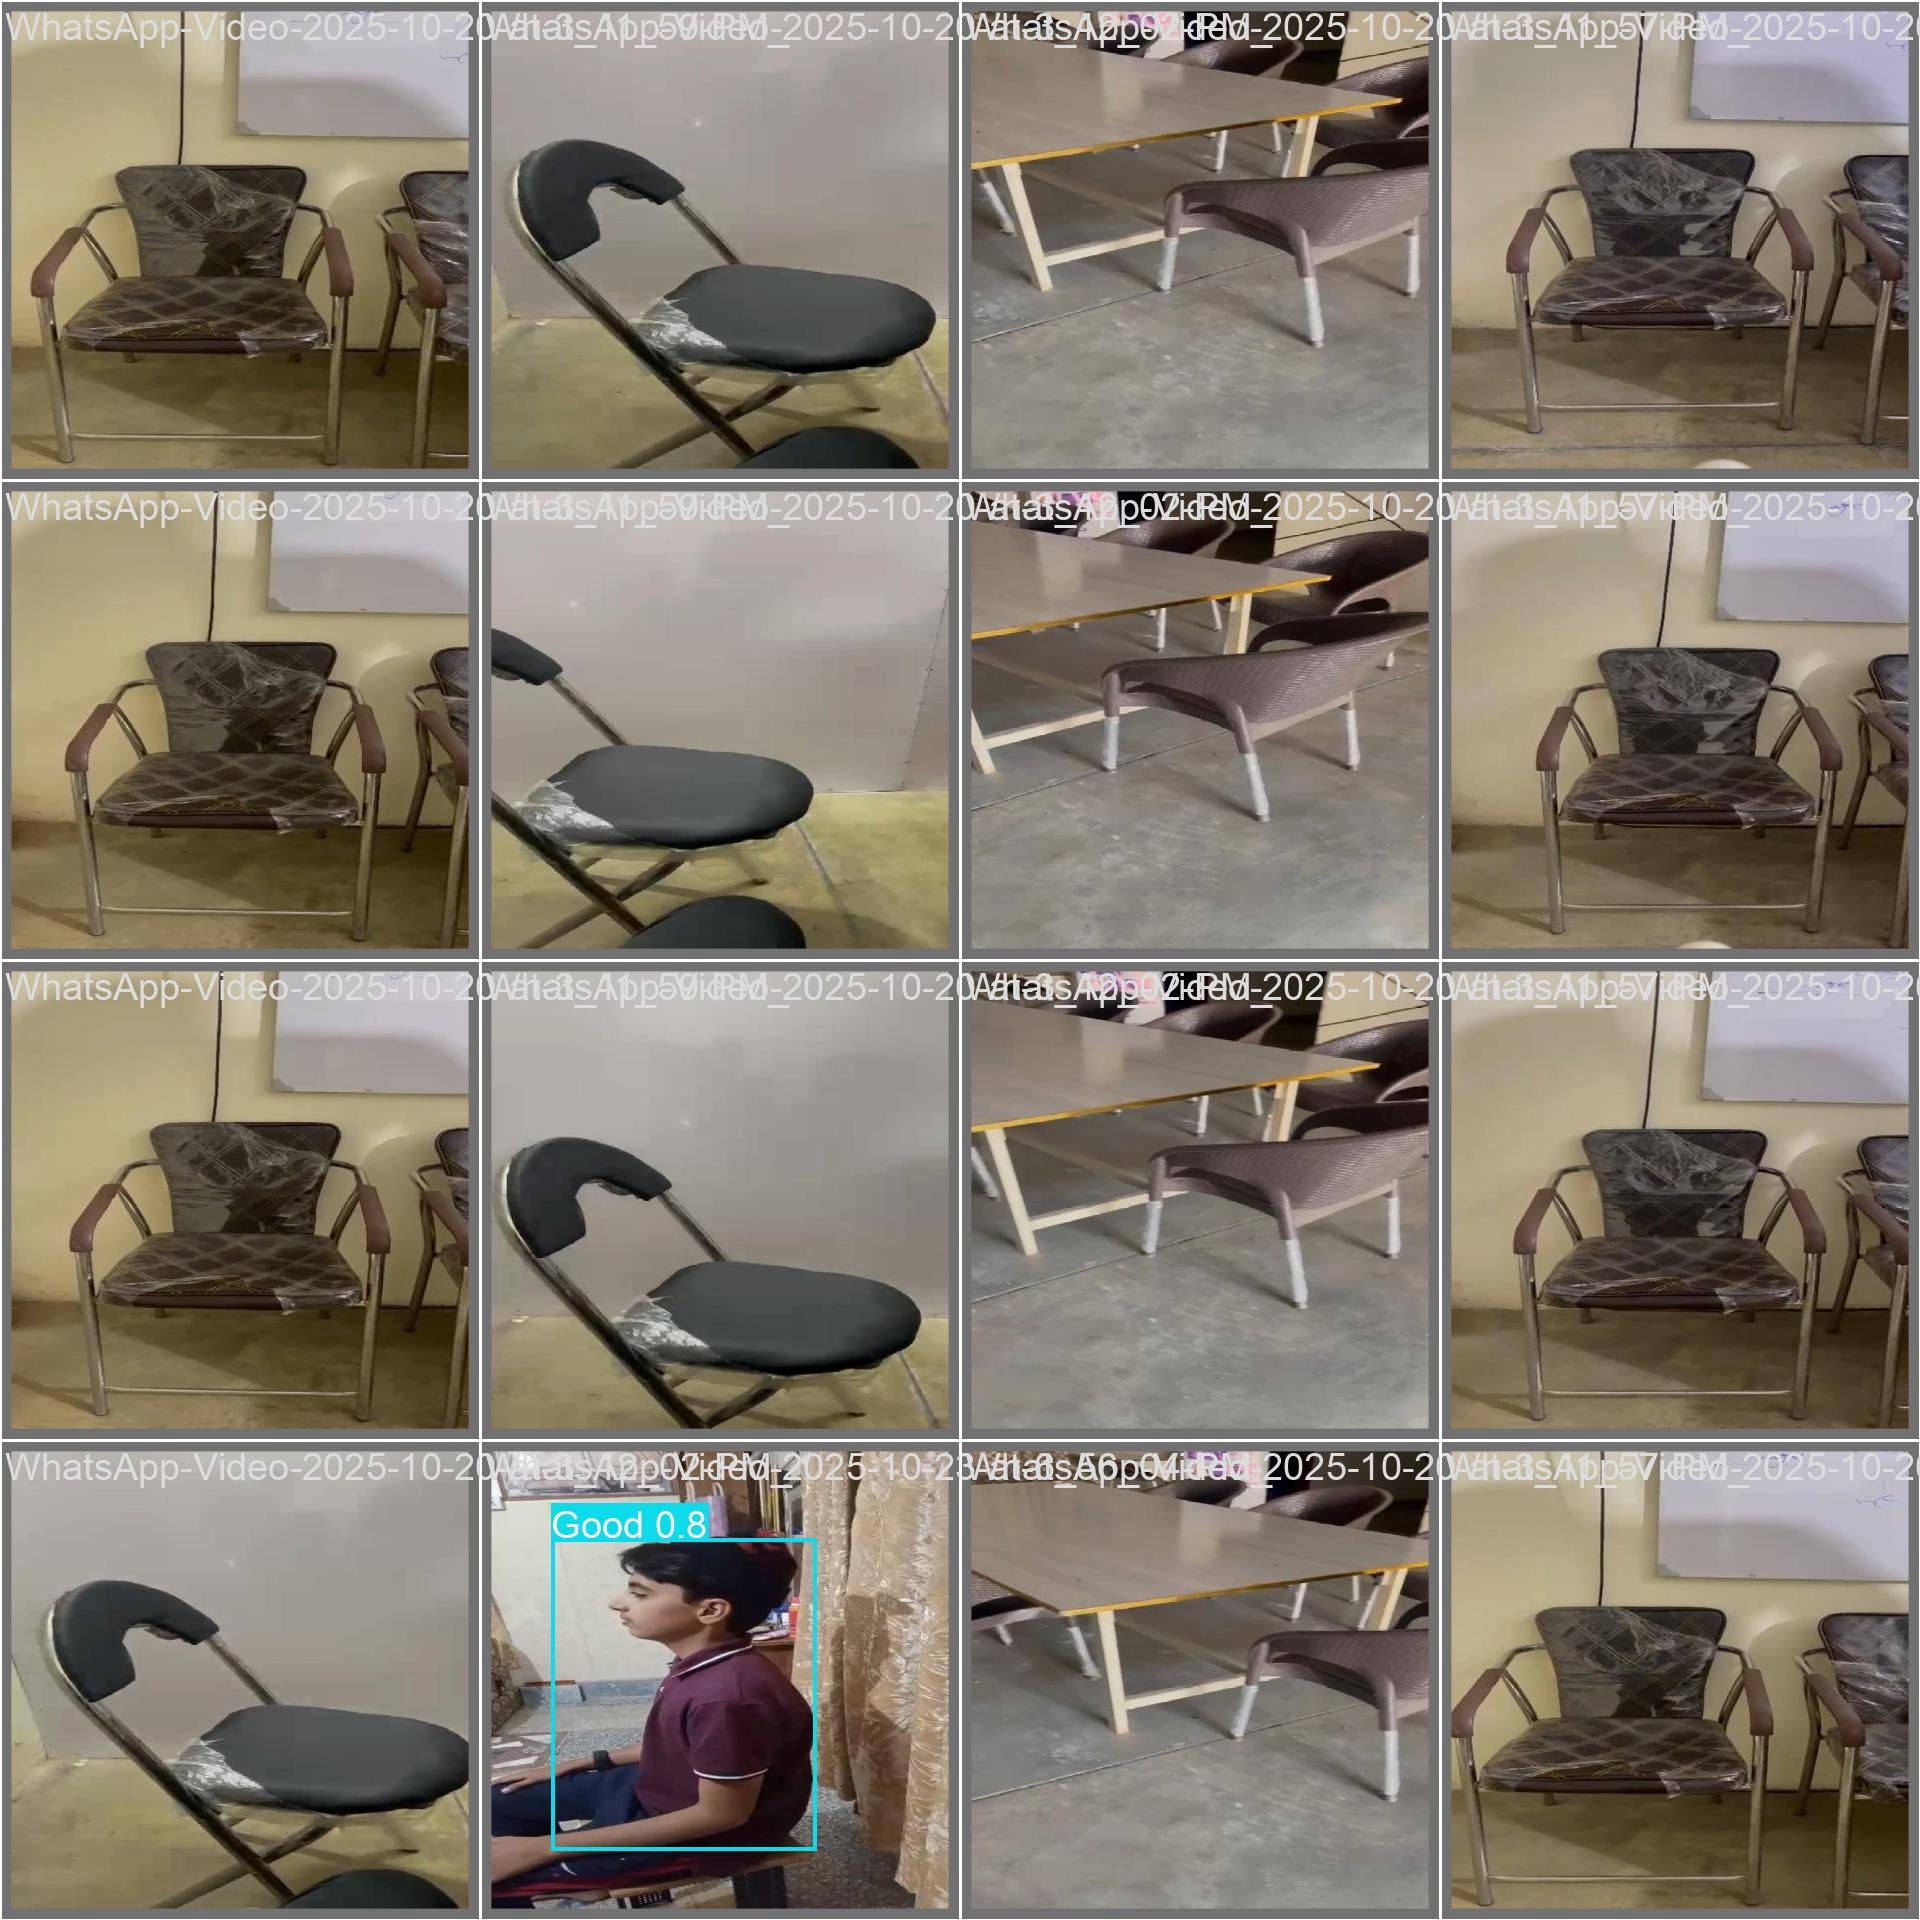

In [ ]:
Image(filename='/kaggle/working/runs/rf_yolov8m_512px_v12/val_batch2_pred.jpg', width=900)

In [ ]:
HOME='/kaggle/working/'

In [ ]:
!yolo task=detect mode=predict model={HOME}runs/rf_yolov8m_512px_v12/weights/best.pt conf=0.50 source={dataset.location}/test/images save=True

Ultralytics 8.3.191 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/54 /kaggle/working/Posture-Detection-10/test/images/0_jpg.rf.acc833149c3cac8be9ca59260d16873e.jpg: 640x640 1 Bad, 36.4ms
image 2/54 /kaggle/working/Posture-Detection-10/test/images/15_jpg.rf.9937241bf9faad876b8adf27e74634dd.jpg: 640x640 1 Good, 16.3ms
image 3/54 /kaggle/working/Posture-Detection-10/test/images/1_jpg.rf.169879de0d61997bd3fc14eeb69fb372.jpg: 640x640 (no detections), 16.2ms
image 4/54 /kaggle/working/Posture-Detection-10/test/images/94_jpg.rf.2df6676b6586e356654c254bcee9f707.jpg: 640x640 1 Bad, 16.2ms
image 5/54 /kaggle/working/Posture-Detection-10/test/images/99_jpg.rf.b2f634b26d743e6333ffb4f18f9333f3.jpg: 640x640 1 Bad, 16.2ms
image 6/54 /kaggle/working/Posture-Detection-10/test/images/Sitting-Posture-Correction_mp4-0066_jpg.rf.37b85da2a0ae3372c24429be81bcc7ff.jpg: 640x640 1 Good, 16.2ms
image 7/54 

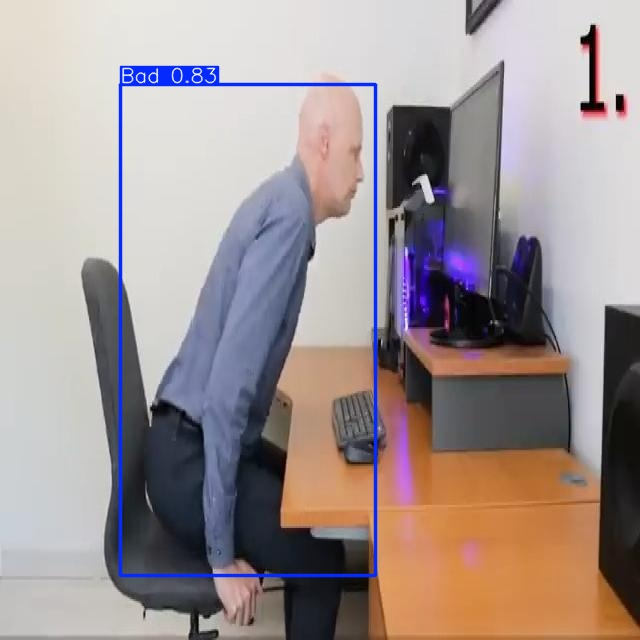

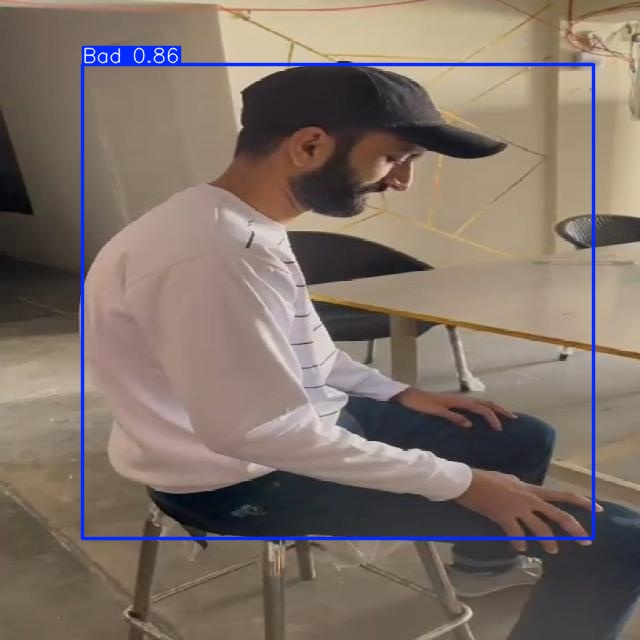

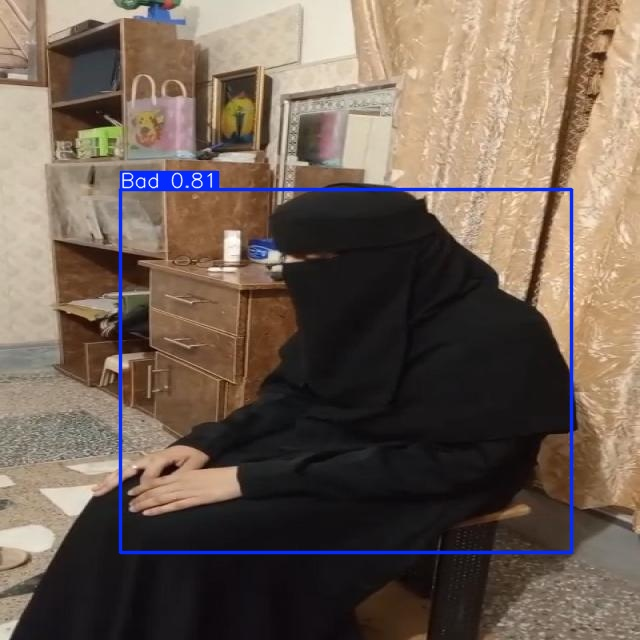

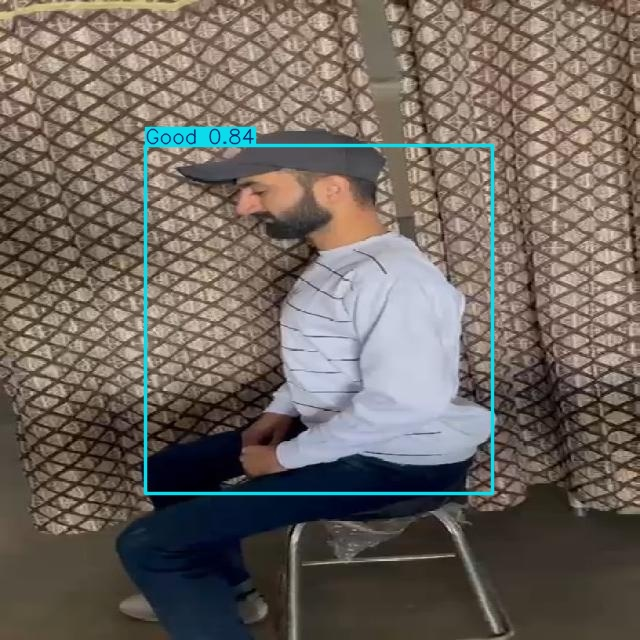

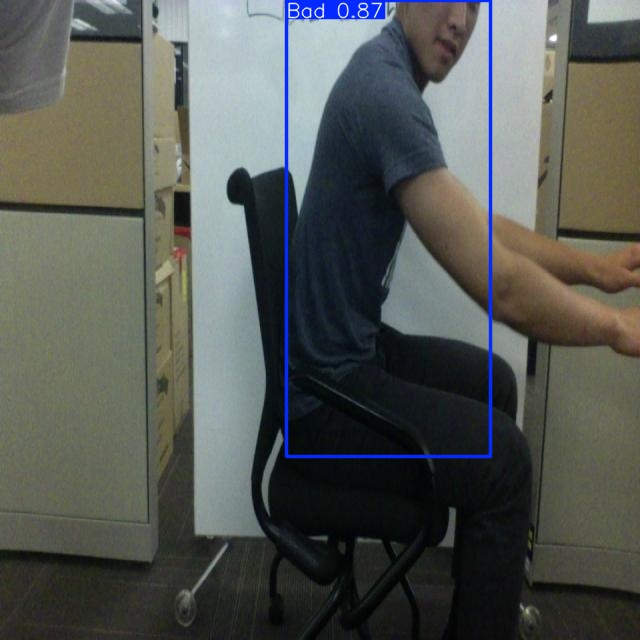

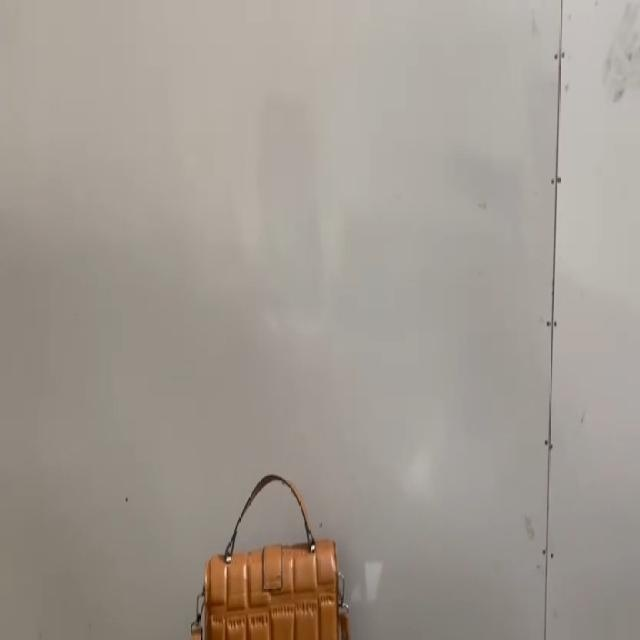

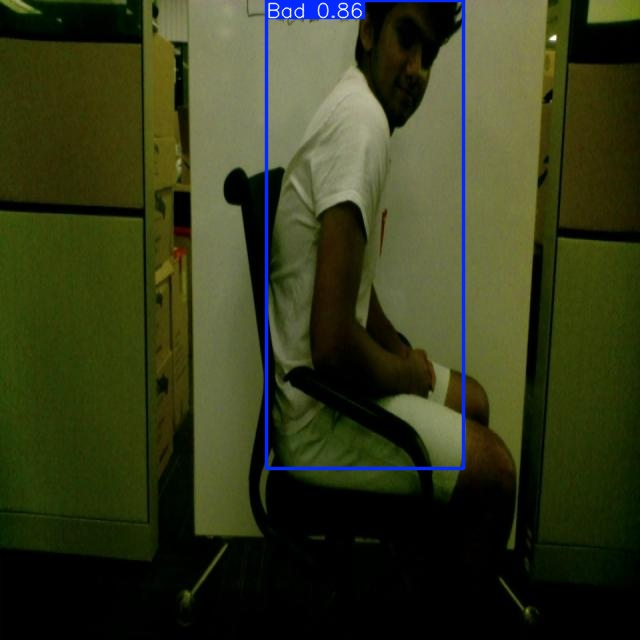

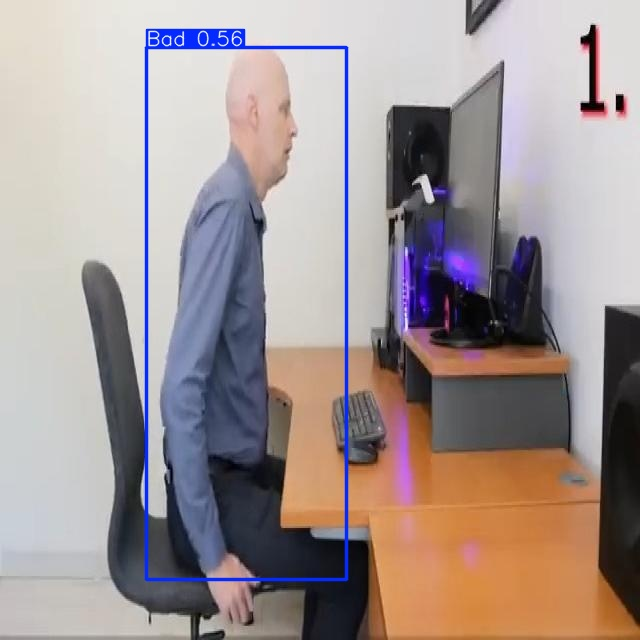

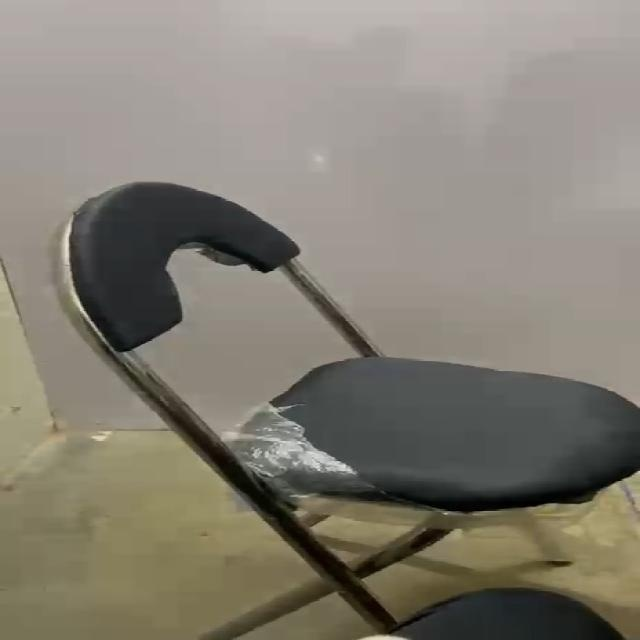

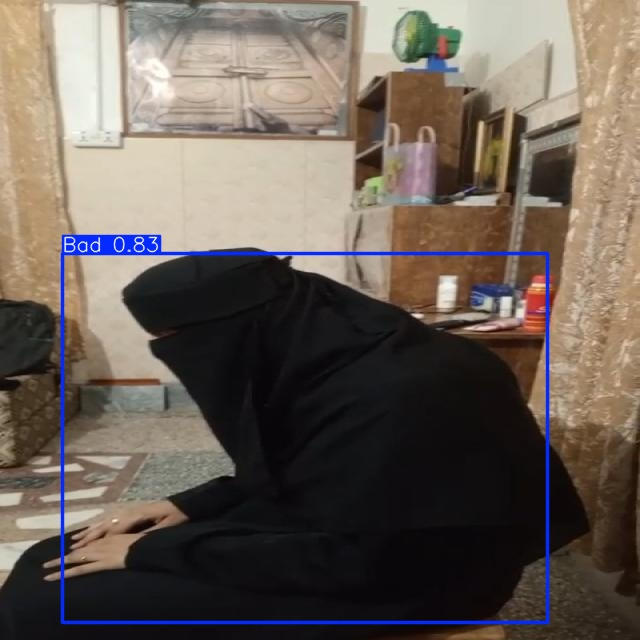

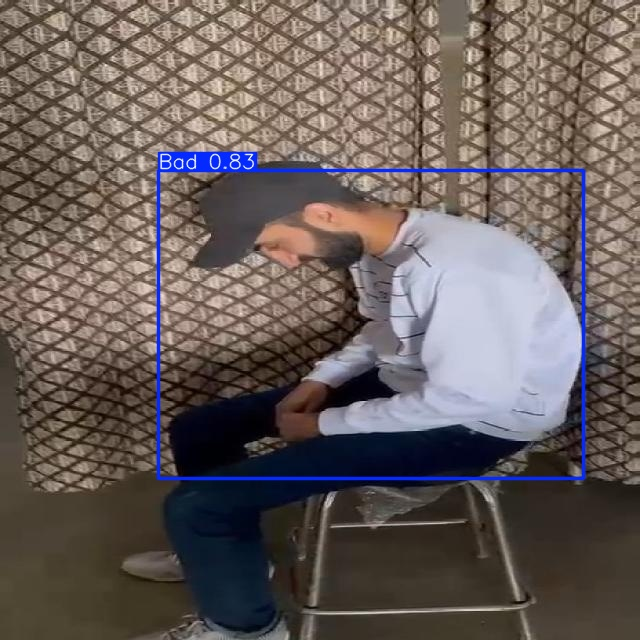

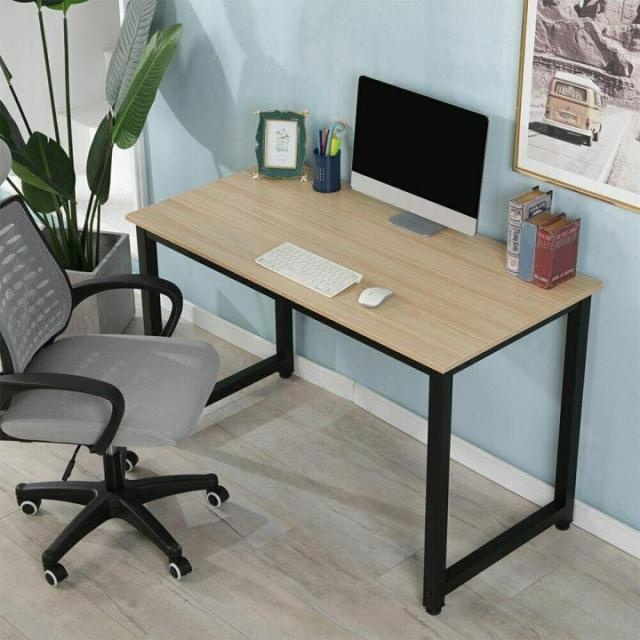

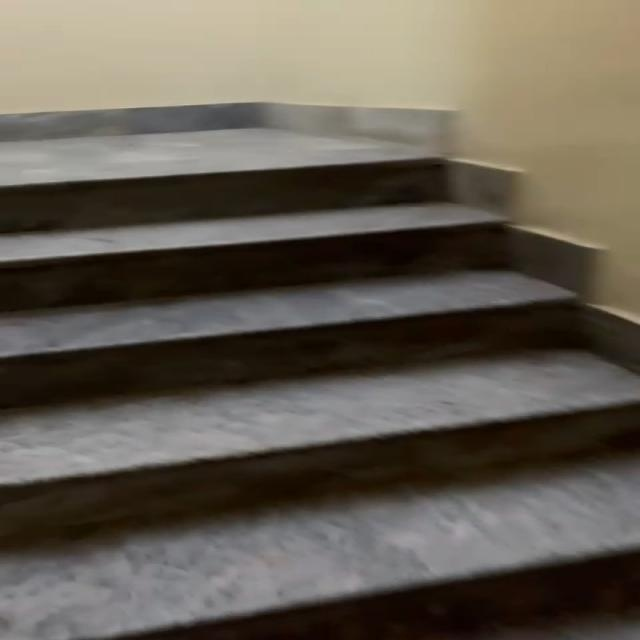

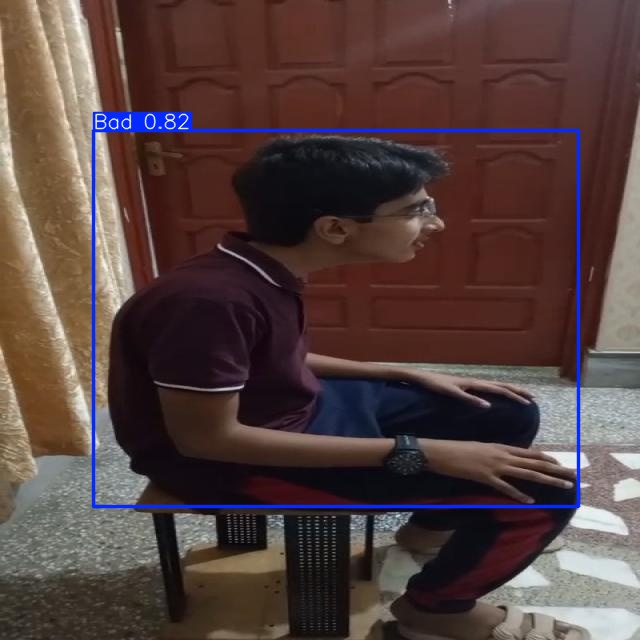

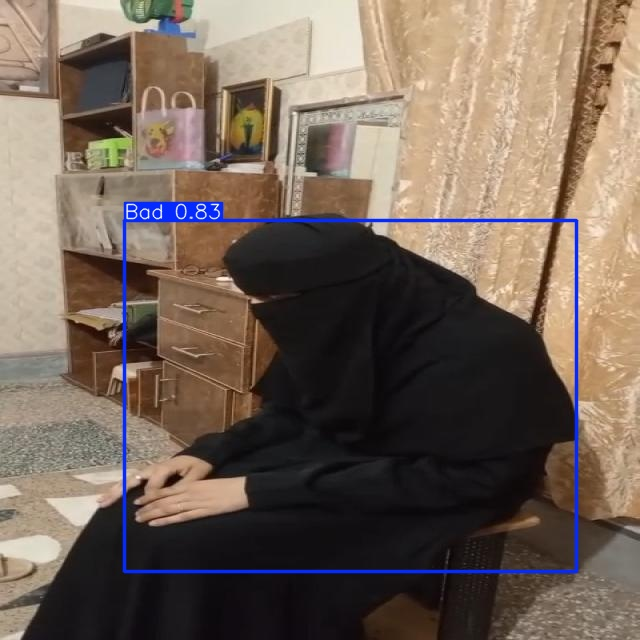

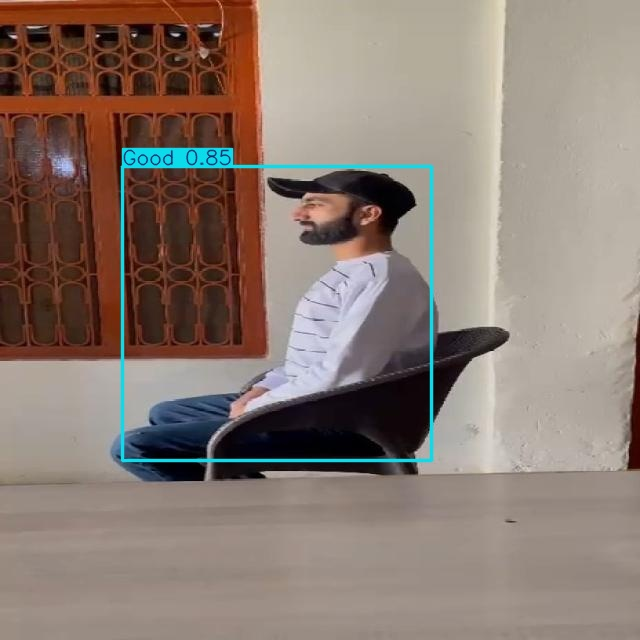

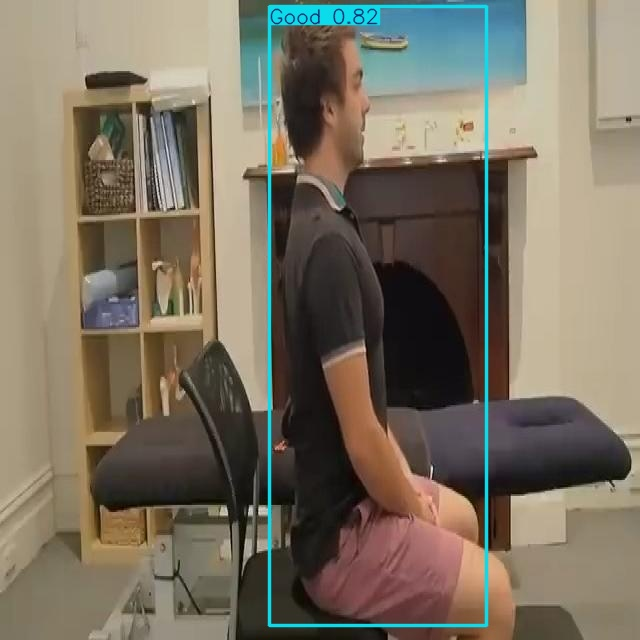

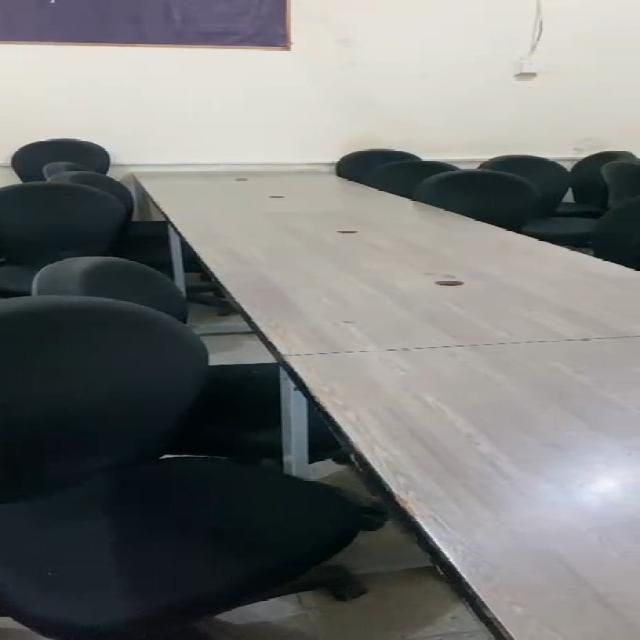

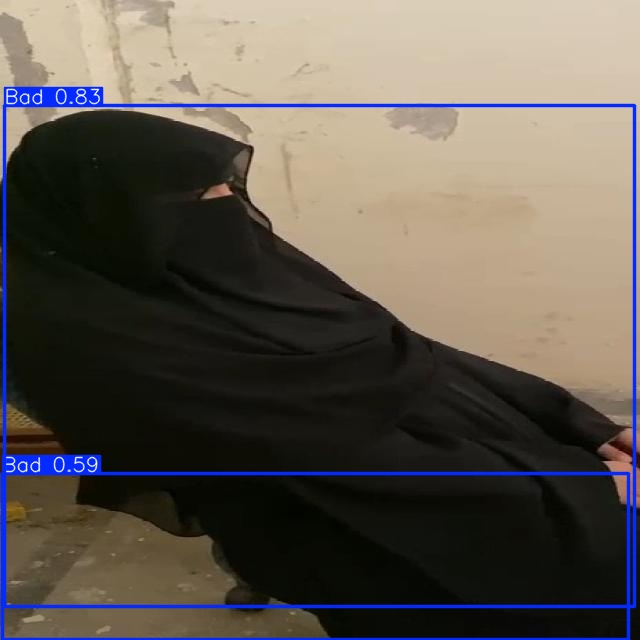

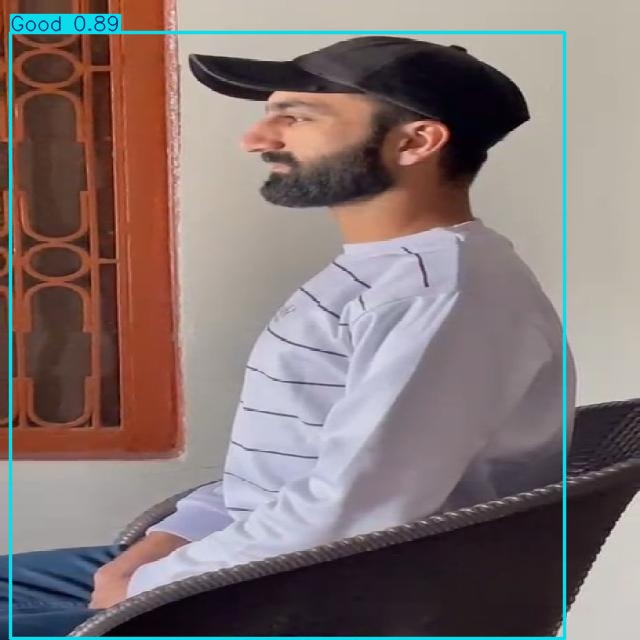

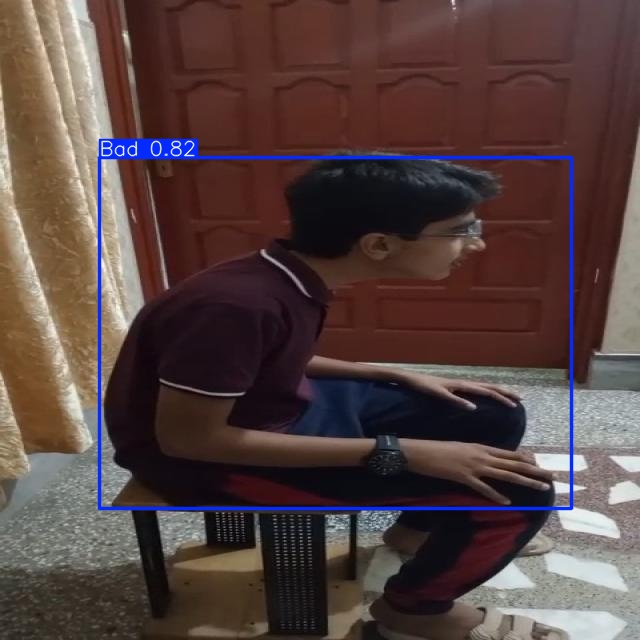

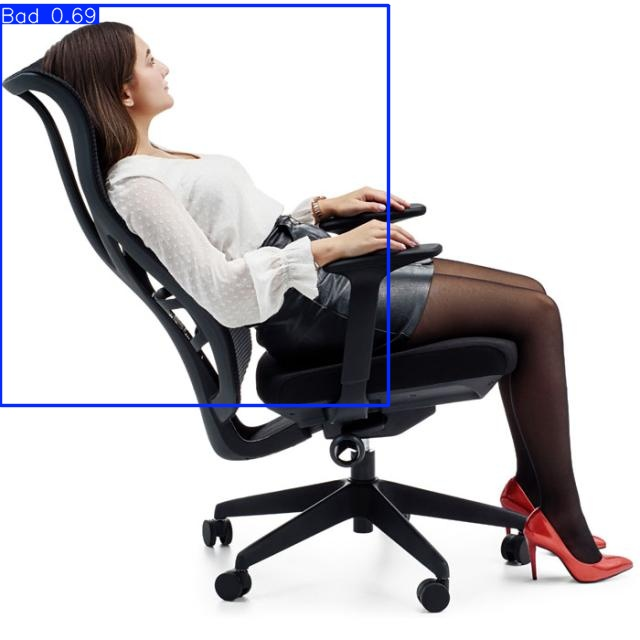

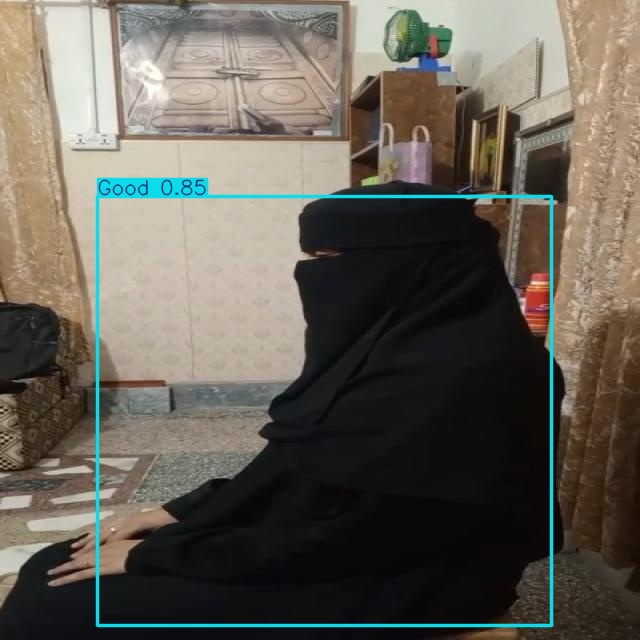

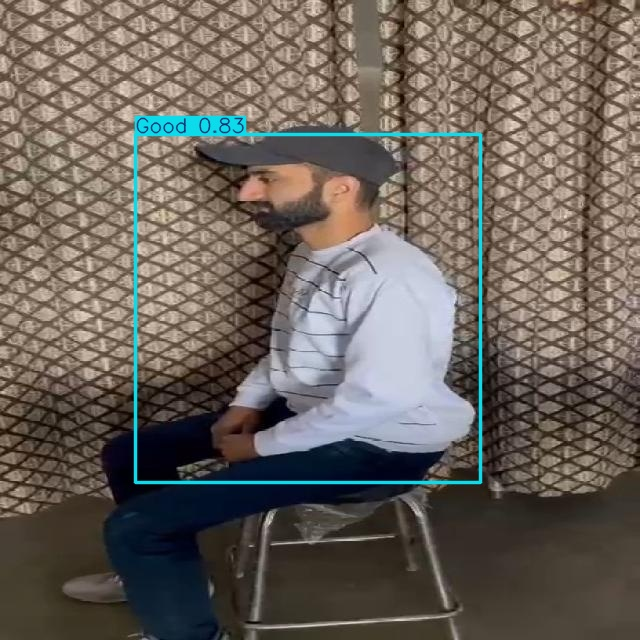

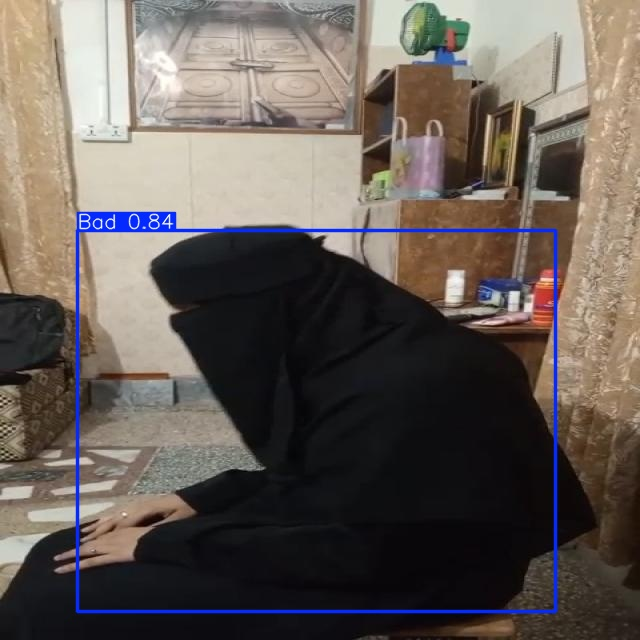

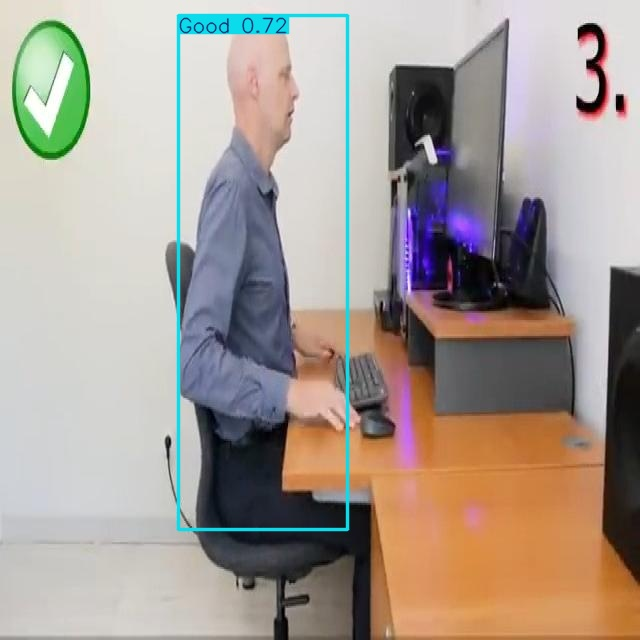

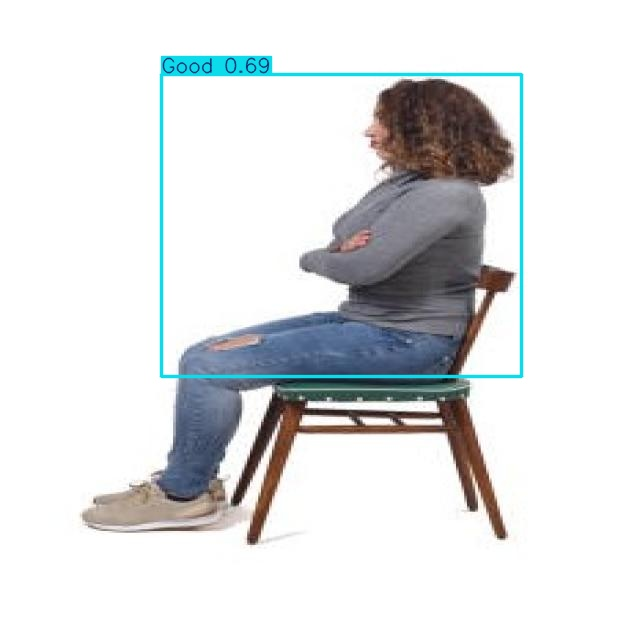

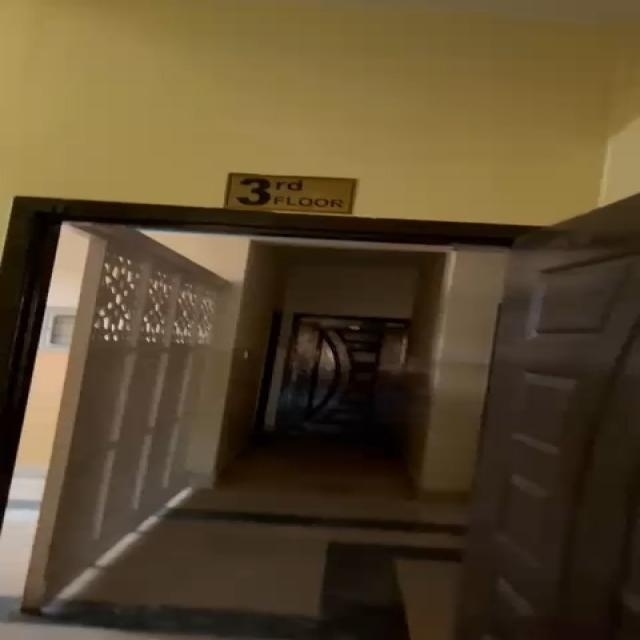

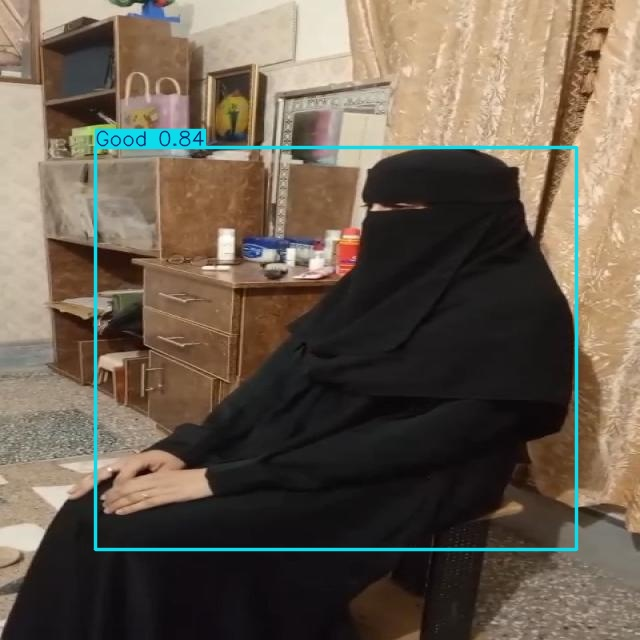

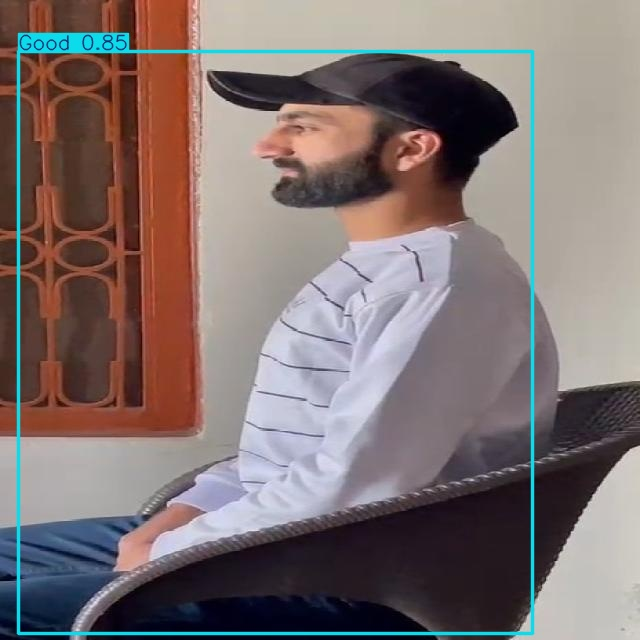

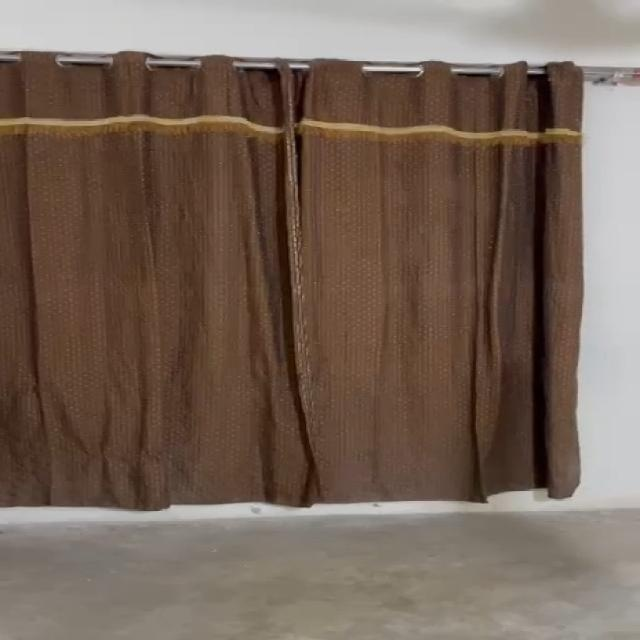

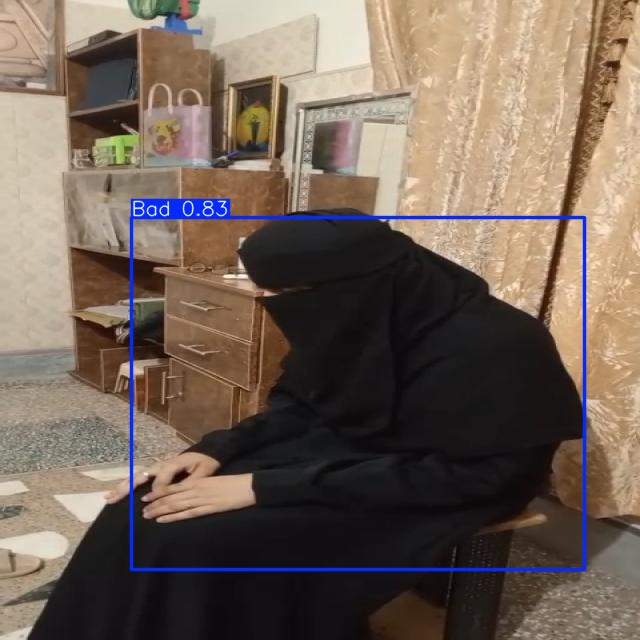

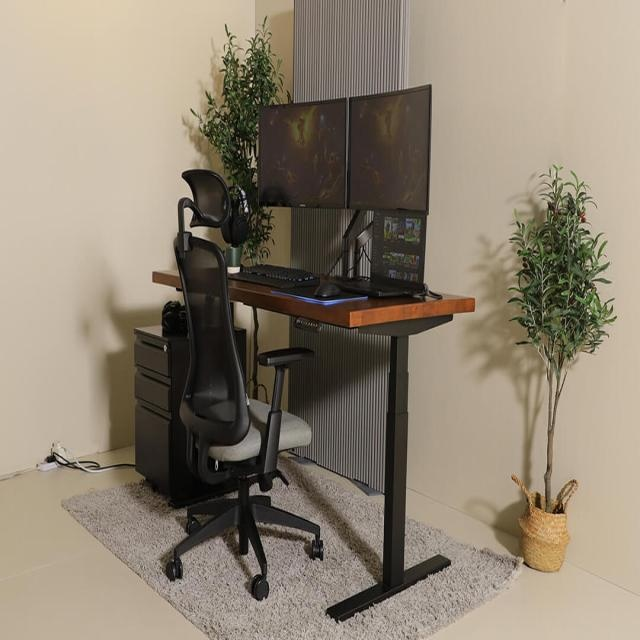

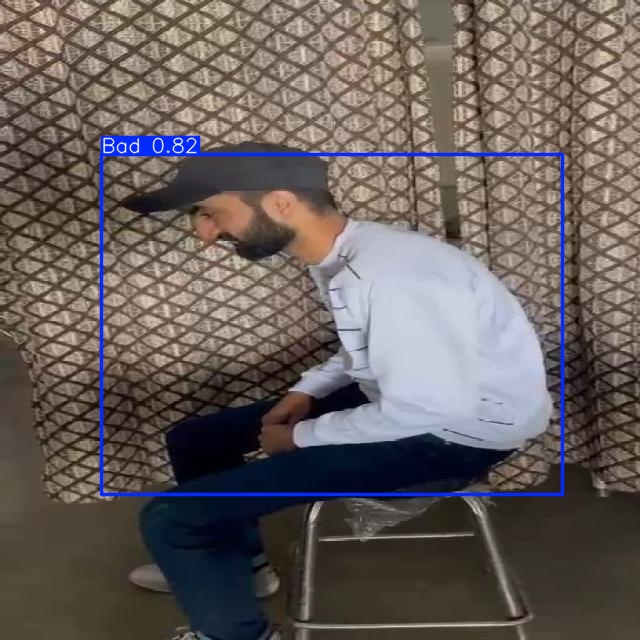

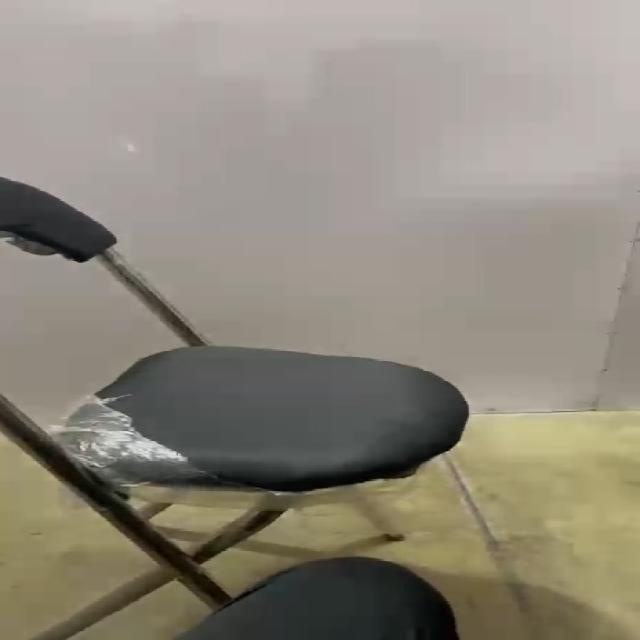

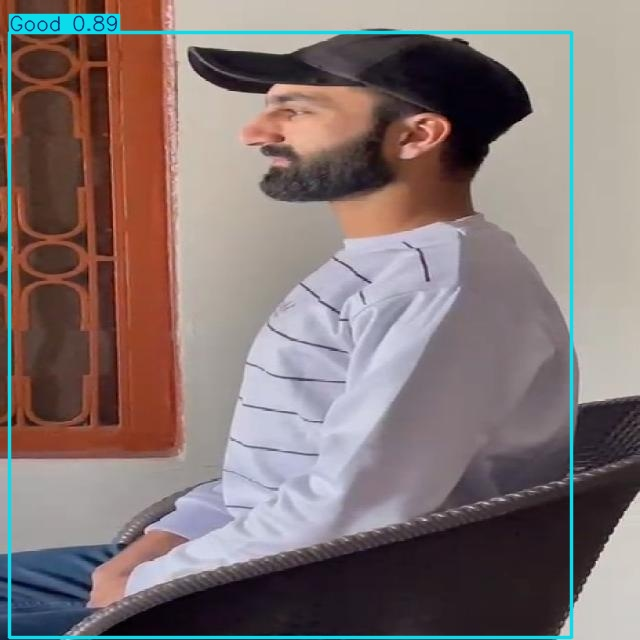

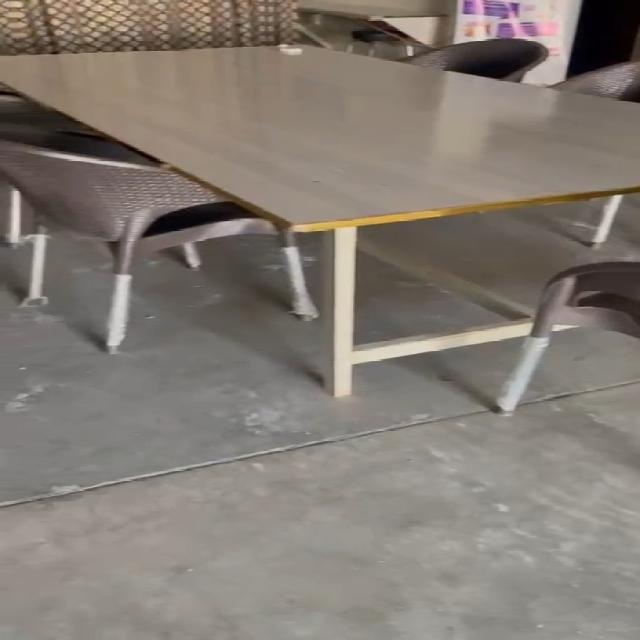

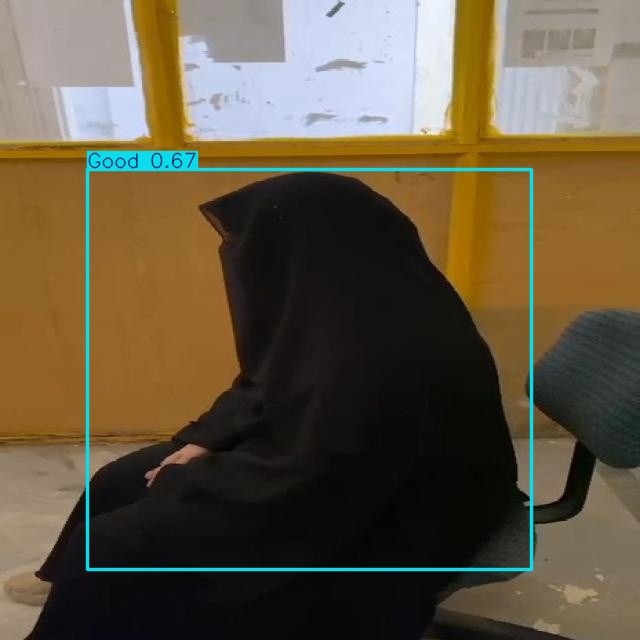

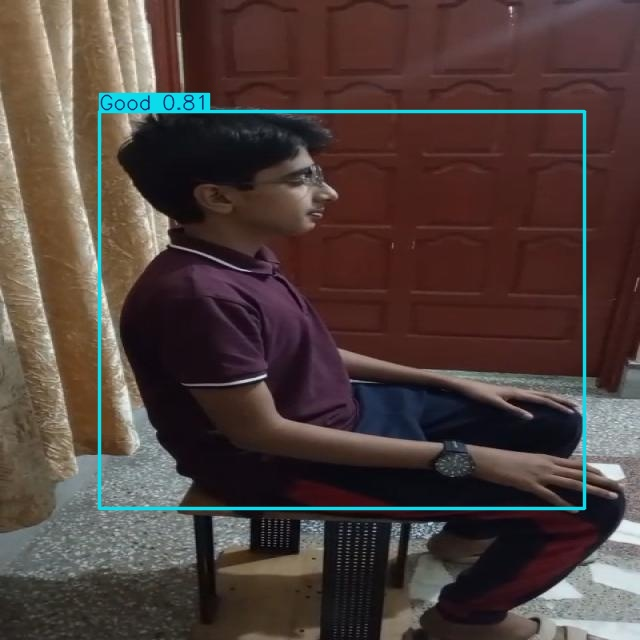

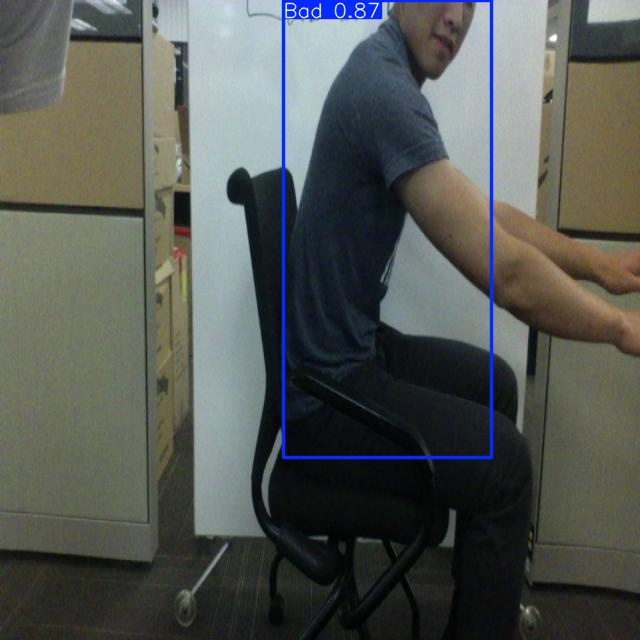

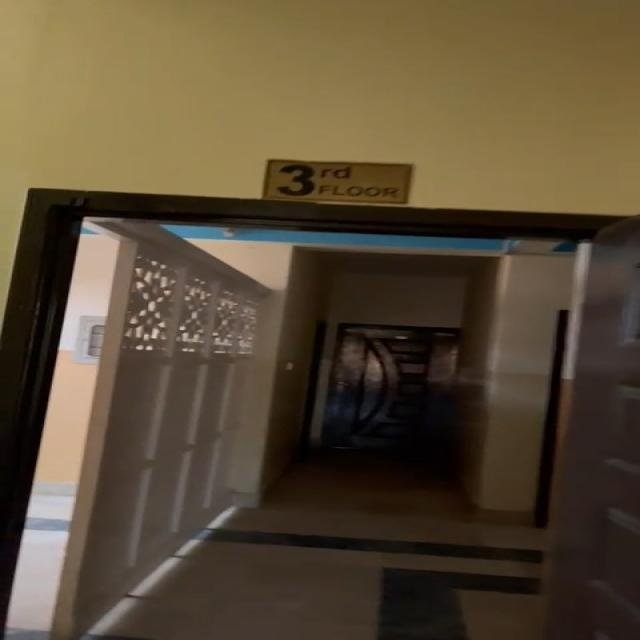

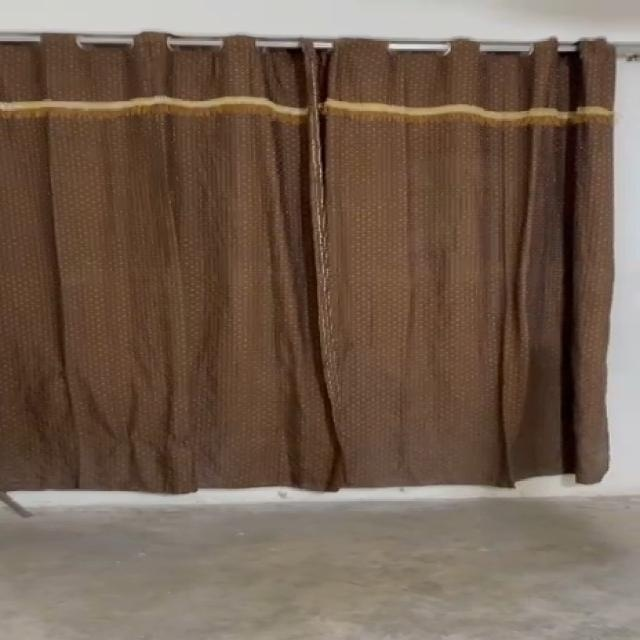

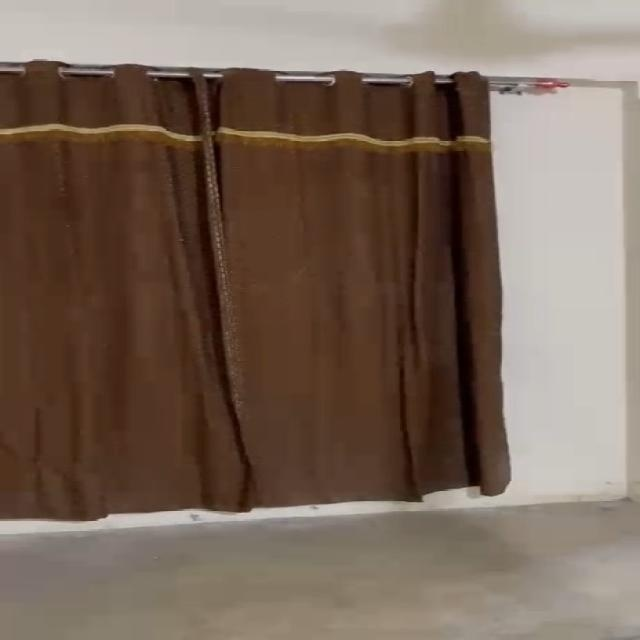

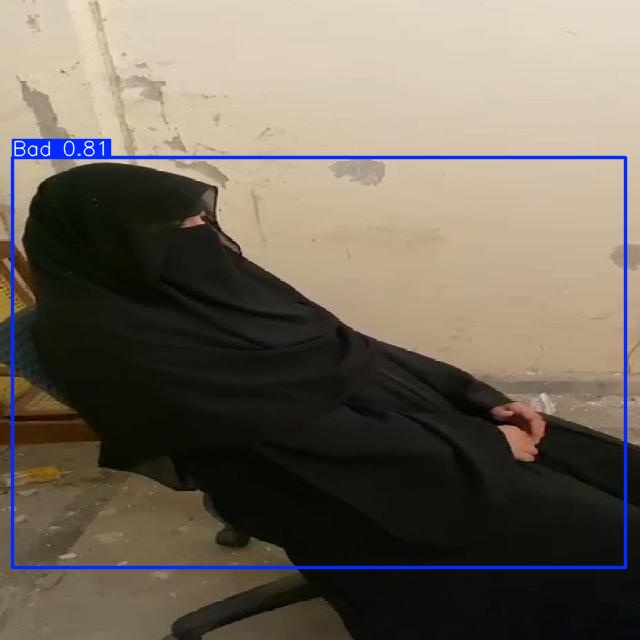

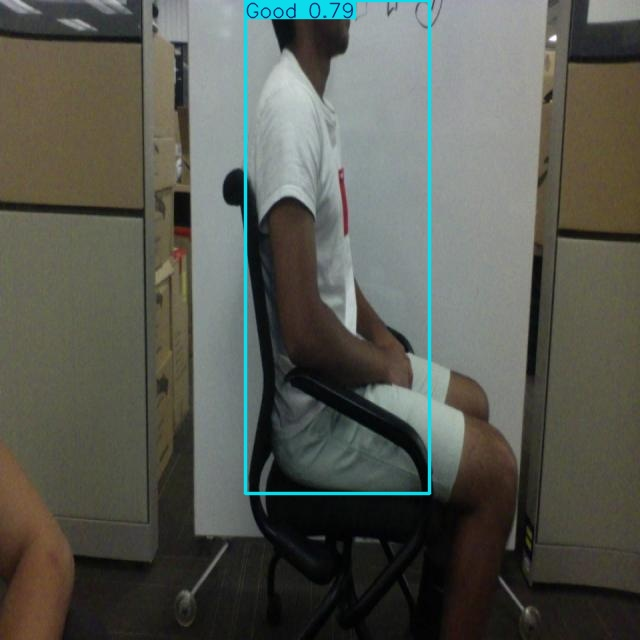

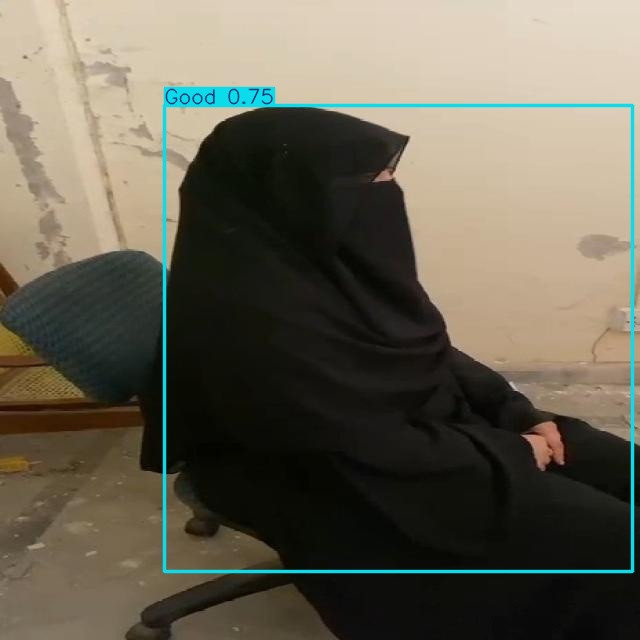

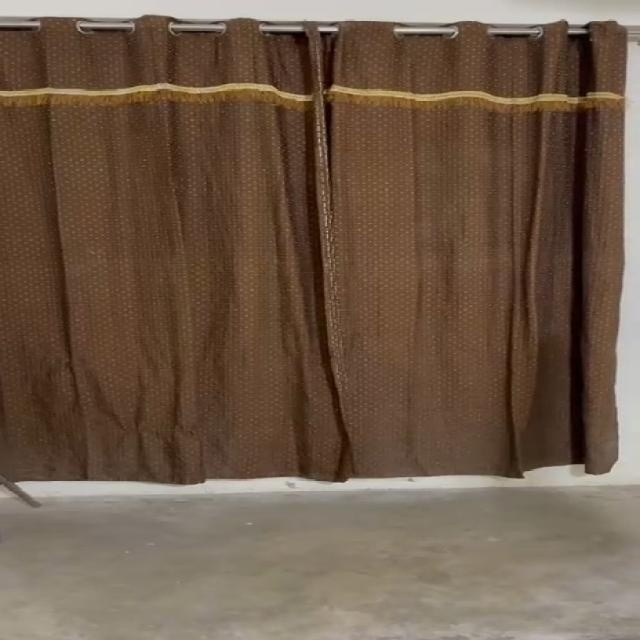

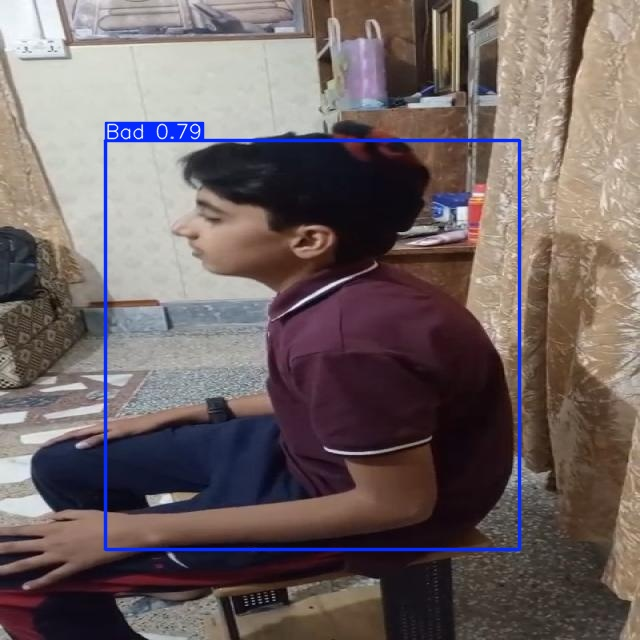

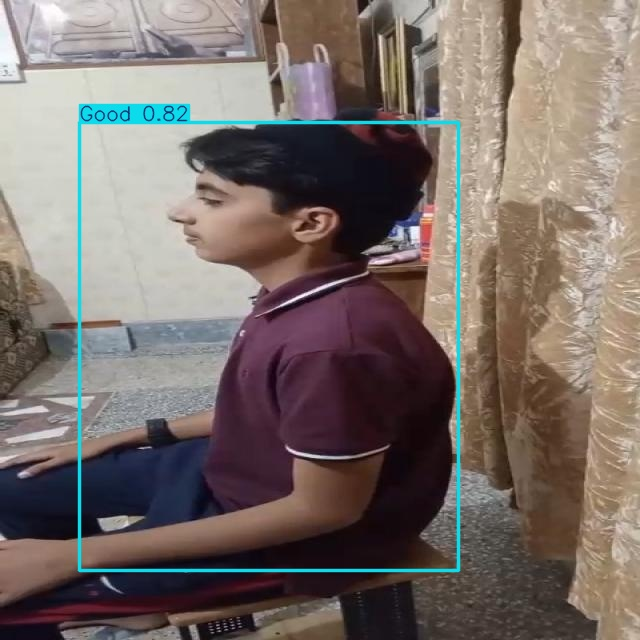

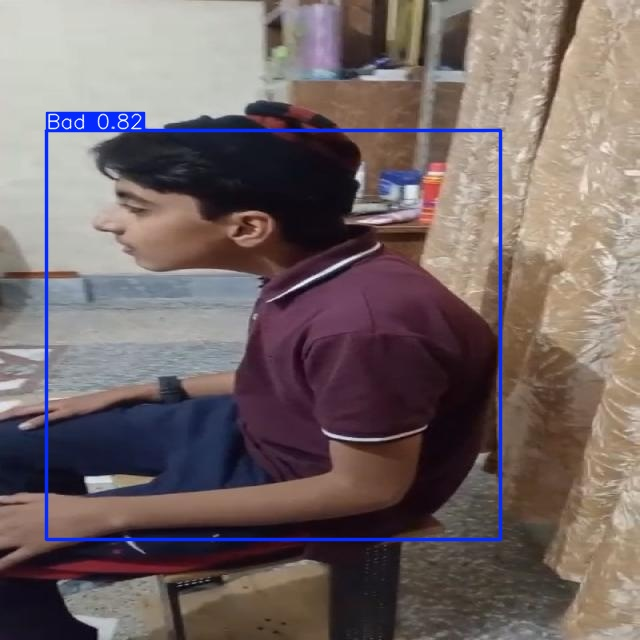

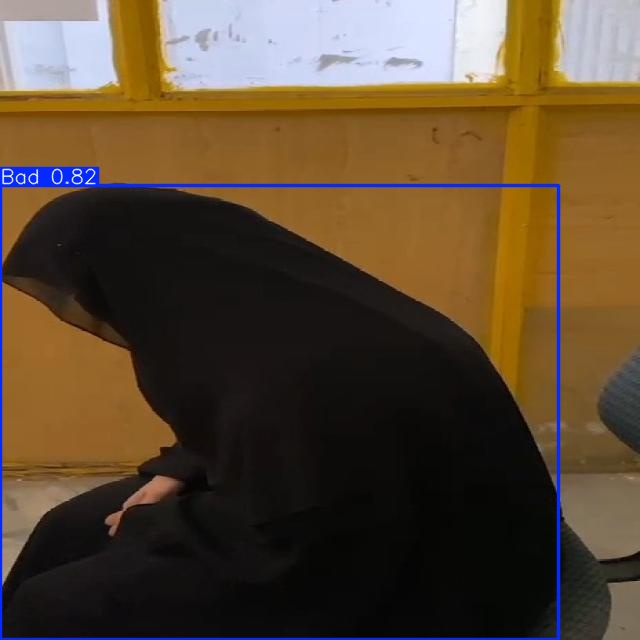

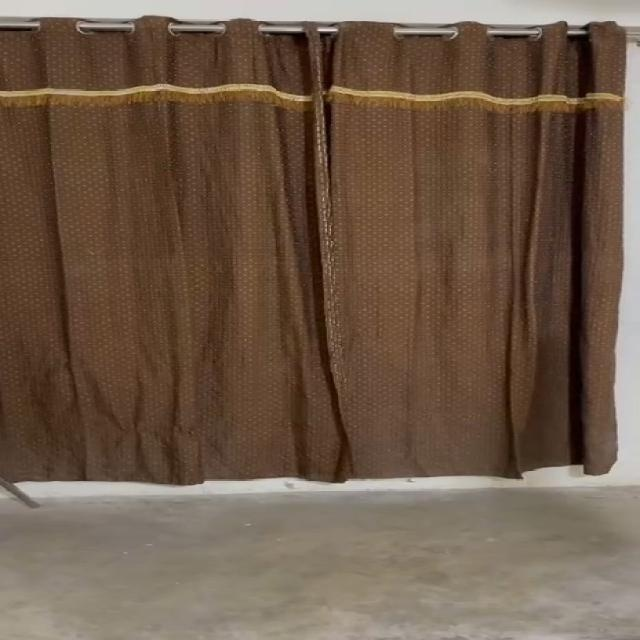

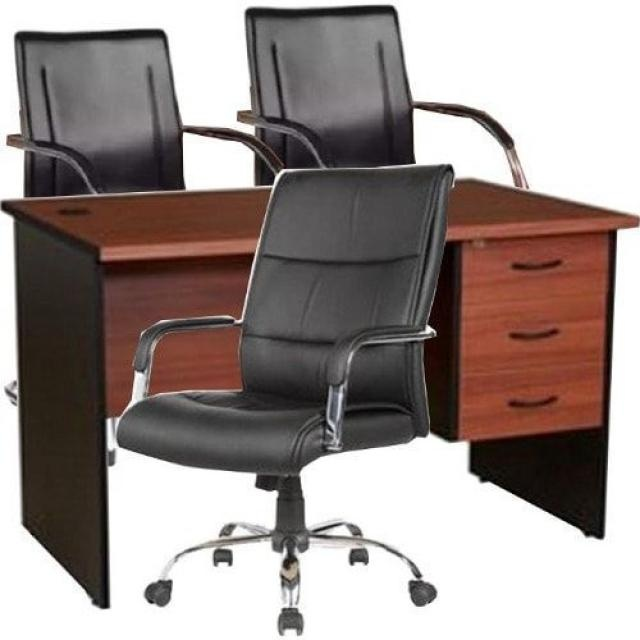

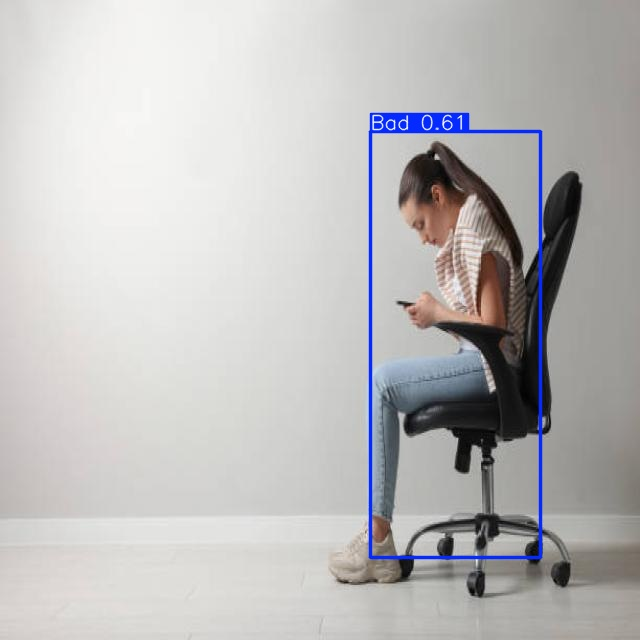

In [ ]:
# Define the base path where the folders are located
base_path = '/kaggle/working/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:100]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")